In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from scipy.integrate import solve_ivp

In [ ]:
def stateSwitchDerivative(t,
                          y,
                          k_nToPhi,
                          k_phiToN,
                          m):
  '''This function returns the derivative
  for a system of differential equations
  modeling the normal liver cell receiving
  inflammation and then switching to an
  inflammatory state: the goal is to ascertain
  how the exponent attached to inflammation
  affects the the amount of switching that
  occurs for a fixed amount of inflammation'''

  L_N = y[0]
  L_phi = y[1]
  phi = y[2]

  return [
      -1 * k_nToPhi * L_N * (phi**m) + 1 * k_phiToN * L_phi,
      1 * k_nToPhi * L_N * (phi**m) - 1 * k_phiToN * L_phi,
      0
  ]


In [ ]:
y0 = [1, 0, 0.5]
k_nToPhi = 1
k_phiToN = 1
m = 5

stateSwitchExperiment = solve_ivp(stateSwitchDerivative, [0, 100], y0, args = (k_nToPhi, k_phiToN, m))

L_NVsTime = stateSwitchExperiment["y"][0]
L_PhiVsTime = stateSwitchExperiment["y"][1]
PhiVsTime = stateSwitchExperiment["y"][2]
timeVals = stateSwitchExperiment["t"]

plt.plot(timeVals, L_NVsTime, label = "L_N")
plt.plot(timeVals, L_PhiVsTime, label = "L_Phi")
plt.plot(timeVals, PhiVsTime, label = "Phi")

plt.legend()


In [ ]:
finalLPhiLNRatioVals = []

for k in range(11):
  y0 = [1, 0, 0.5]
  k_nToPhi = 1
  k_phiToN = 1
  m = k

  stateSwitchExperiment = solve_ivp(stateSwitchDerivative, [0, 100], y0, args = (k_nToPhi, k_phiToN, m))

  L_NVsTime = stateSwitchExperiment["y"][0]
  finalLNVal = L_NVsTime[-1]

  L_PhiVsTime = stateSwitchExperiment["y"][1]
  finalLPhiVal = L_PhiVsTime[-1]

  PhiVsTime = stateSwitchExperiment["y"][2]
  timeVals = stateSwitchExperiment["t"]

  finalLPhiLNRatioVals.append(finalLPhiVal / finalLNVal)

print(finalLPhiLNRatioVals)

plt.title("Final Ratio of L_Phi to L_N vs. m, with phi = 0.5")
plt.plot(range(11), finalLPhiLNRatioVals, label = "Final Ratio of L_Phi to L_N")
plt.legend()

plt.xlabel("m")
plt.ylabel("L_Phi/L_N")

plt.show()


In [ ]:
numberMsToTry = 6
numberPhisToTry = 301
timeLimit = 100

finalLPhiVals = np.zeros((numberMsToTry, numberPhisToTry))

for j in range(numberMsToTry):
  for k in range(numberPhisToTry):
    y0 = [1, 0, k * 0.01]
    k_nToPhi = 1
    k_phiToN = 1
    m = j

    stateSwitchExperiment = solve_ivp(stateSwitchDerivative, [0, timeLimit], y0, args = (k_nToPhi, k_phiToN, m))

    L_NVsTime = stateSwitchExperiment["y"][0]

    L_PhiVsTime = stateSwitchExperiment["y"][1]
    finalLPhiVal = L_PhiVsTime[-1]

    PhiVsTime = stateSwitchExperiment["y"][2]
    timeVals = stateSwitchExperiment["t"]

    finalLPhiVals[j][k] = finalLPhiVal

  plt.plot(np.arange(numberPhisToTry) * 0.01, finalLPhiVals[j][:], label = f"Liver Inflammation Response with m = {m}")

#print(finalLPhiVals)

plt.title("Final Value of L_Phi (Liver Inflammatory Response) vs. phi")
#plt.plot(np.arange(numberPhisToTry) * 0.01, finalLPhiVals, label = "Liver Inflammation Response")
plt.legend()

plt.xlabel("Phi")
plt.ylabel("Final L_Phi")

plt.xlim((0 - 0.05, numberPhisToTry * 0.01 + 0.05))
plt.ylim((0, 1.05))

plt.show()


In [ ]:
def liverAminoSubModel(t,
                       y,
                       _k_nToD,
                       _k_DToN,
                       _k_A,
                       _b):
  '''This function returns the derivative
  of a system of differential equations
  modeling the way in which the liver may
  keep a balance of amino acids in the body
  by entering an amino-acid generating state
  and then reverting back when encountering
  a lot of amino acids'''

  L_N = y[0]
  L_D = y[1]
  A = y[2]

  return [
      -1 * _k_nToD * L_N + 1 * _k_DToN * (A**_b) * L_D,
      1 * _k_nToD * L_N - 1 * _k_DToN * (A**_b) * L_D,
      1 * _k_A * L_D - _b * _k_DToN * (A**_b) * L_D
  ]


In [ ]:
y0 = [1, 0, 2]
k_nToD = 1
k_DToN = 1
k_A = 1
b = 12

liverSubmodel = solve_ivp(liverAminoSubModel, [0, 100], y0, args = (k_nToD, k_DToN, k_A, b))

L_NVsTime = liverSubmodel["y"][0]
L_DVsTime = liverSubmodel["y"][1]
AVsTime = liverSubmodel["y"][2]
timeVals = liverSubmodel["t"]

plt.plot(timeVals, L_NVsTime, label = "L_N")
plt.plot(timeVals, L_DVsTime, label = "L_D")
plt.plot(timeVals, AVsTime, label = "A")

plt.legend()

plt.xlabel("Time")
plt.ylabel("Liver Cell/Amino Acid Concentration")

plt.title(f"Liver Submodel Pops vs. Time for b = {b}, k_A = {k_A}, k_DToN = {k_DToN}")

In [ ]:
def muscleAminoSubModel(t,
                       y,
                       _k_nToD,
                       _k_DToN,
                       _k_mb,
                       _k_mg,
                       _c,
                       _epsilon):
  '''This function returns the derivative
  of a system of differential equations
  modeling the way in which the liver may
  keep a balance of amino acids in the body
  by entering an amino-acid generating state
  and then reverting back when encountering
  a lot of amino acids'''

  M_N = y[0]
  M_D = y[1]
  A = y[2]

  return [
      -1 * _k_nToD * M_N + 1 * _k_DToN * (A**c) * M_D + 1 * _k_mg * (A**epsilon) * M_N,
      1 * _k_nToD * M_N - 1 * _k_DToN * (A**c)* M_D - 1 * k_mb * M_D,
      - c * _k_DToN * (A**c) * M_D + epsilon * k_mb * M_D - epsilon * _k_mg * (A**epsilon) * M_N + 10
  ]

  '''return [
      -M_N + (A) * M_D + (A) * M_N,
      M_N - (A)* M_D,
      - (A) * M_D + M_D + (A) * M_N
  ]'''

In [ ]:
y0 = [1, 1, 1]
k_nToD = 1
k_DToN = 1
k_mb = 1
k_mg = 1
c = 1
epsilon = 1

print(muscleAminoSubModel(0, y0, k_nToD, k_DToN, k_mb, k_mg, c, epsilon))

In [ ]:
y0 = [1, 0, 1]
k_nToD = 1
k_DToN = 1
k_mb = 1
k_mg = 1
c = 1
epsilon = 1

muscleSubmodel = solve_ivp(muscleAminoSubModel, [0, 1000], y0, args = (k_nToD, k_DToN, k_mb, k_mg, c, epsilon))

M_NVsTime = muscleSubmodel["y"][0]
M_DVsTime = muscleSubmodel["y"][1]
muscleAVsTime = muscleSubmodel["y"][2]
timeVals = muscleSubmodel["t"]

plt.plot(timeVals, M_NVsTime, label = "M_N")
plt.plot(timeVals, M_DVsTime, label = "M_D")
plt.plot(timeVals, muscleAVsTime, label = "A")

plt.plot(timeVals, np.zeros(len(timeVals)), 'k-')

plt.legend()

plt.xlabel("Time")


plt.ylabel("Muscle Cell/Amino Acid Concentration")

plt.title(f"Muscle Submodel Pops vs. Time for c = {c}, k_mb = {k_mb}, k_DToN = {k_DToN}")
plt.show()
#plt.title(f"Muscle Submodel Pops vs. Time for c = {c}, all else 1")

In [ ]:
def liverMuscleCombo(t,
                     y,
                     _k_LD,
                     _k_LF,
                     _k_MD,
                     _k_MF,
                     _k_A,
                     _b,
                     _c,
                     _k_mb,
                     _k_mg
                     ):

  L_N = y[0]
  L_D = y[1]
  M_N = y[2]
  M_D = y[3]
  A = y[4]

  return [
      - 1 * _k_LD * L_N + 1 * _k_LF * (A**_b) * L_D,
      1 * _k_LD * L_N - 1 * k_LF * (A**_b) * L_D,
      - 1 * _k_MD * M_N + 1 * _k_MF * (A**_c) * M_D + 1 * _k_mg * (A**epsilon) * M_N,
      1 * _k_MD * M_N - 1 * _k_MF * (A**_c) * M_D - 1 * _k_mb * M_D,
      (1 * k_A * L_D - _b * k_LF * (A**_b) * L_D) + (epsilon * _k_mb * M_D - c * _k_MF * (A**_c) * M_D - epsilon * _k_mg * (A**epsilon) * M_N)
  ]

'''
#Full muscle submodel
  return [
        0,
        0,
        - 1 * _k_MD * M_N + 1 * _k_MF * (A**_c) * M_D + 1 * _k_mg * (A**epsilon) * M_N,
        1 * _k_MD * M_N - 1 * _k_MF * (A**_c) * M_D - 1 * _k_mb * M_D,
        epsilon * _k_mb * M_D - c * _k_MF * (A**_c) * M_D - epsilon * _k_mg * (A**epsilon) * M_N
    ]
'''

'''
#Muscle model with breakdown but no growth
  return [
        0,
        0,
        - 1 * _k_MD * M_N + 1 * _k_MF * (A**_c) * M_D,
        1 * _k_MD * M_N - 1 * _k_MF * (A**_c) * M_D - 1 * _k_mb * M_D,
        epsilon * _k_mb * M_D
    ]
'''

'''#Full liver submodel
  return [
      - 1 * _k_LD * L_N + 1 * _k_LF * (A**_b) * L_D,
      1 * _k_LD * L_N - 1 * k_LF * (A**_b) * L_D,
      0,
      0,
      1 * k_A * L_D - _b * k_LF * (A**_b) * L_D
  ]'''

    #Liver submodel sans amino acid production
'''  return [
      - 1 * _k_LD * L_N + 1 * _k_LF * (A**b) * L_D,
      1 * _k_LD * L_N - 1 * k_LF * (A**b) * L_D,
      0,
      0,
      - b * _k_LF * (A**b) * L_D
  ]
'''

In [ ]:
y0 = [1, 0, 0.5, 0, 1]
k_LD = 1
k_LF = 1
k_MD = 1
k_MF = 1
k_A = 1
b = 1
c = 1
k_mb = 1
k_mg = 1


muscleSubmodel = solve_ivp(liverMuscleCombo, [0, 100], y0, args = (k_LD, k_LF, k_MD, k_MF, k_A, b, c, k_mb, k_mg))

L_NVsTime = muscleSubmodel["y"][0]
L_DVsTime = muscleSubmodel["y"][1]
M_NVsTime = muscleSubmodel["y"][2]
M_DVsTime = muscleSubmodel["y"][3]
AVsTime = muscleSubmodel["y"][4]
timeVals = muscleSubmodel["t"]

plt.plot(timeVals, L_NVsTime, label = "L_N")
plt.plot(timeVals, L_DVsTime, label = "L_D")
plt.plot(timeVals, M_NVsTime, label = "M_N")
plt.plot(timeVals, M_DVsTime, label = "M_D")
plt.plot(timeVals, AVsTime, label = "A")

plt.plot(timeVals, np.zeros(len(timeVals)), 'k-')

plt.legend()

plt.xlabel("Time")


plt.ylabel("Liver Cell/Muscle Cell/Amino Acid Concentration")

plt.title(f"Liver-Muscle Model Pops vs. Time")
plt.show()
#plt.title(f"Liver-Muscle Submodel Pops vs. Time for c = {c}, all else 1")

In [ ]:
def woundSubmodelDeriv(t,
                       y,
                       _k_phi,
                       _k_wp,
                       _omega,
                       _rho):

  W = y[0]
  phi = y[1]
  pI = y[2]
  R = y[3]

  return [
      -1 * _k_wp * W * (pI**_omega),
      1 * _k_phi * W,
      - _omega * k_wp * W * (pI**omega),
      _rho * k_wp * W * (pI**omega)
  ]

In [ ]:
y0 = [1, 0, 0.5, 0]
k_phi = 0.01
k_wp = 1
omega = 1
rho = 1

woundSubmodel = solve_ivp(woundSubmodelDeriv, [0, 100], y0, args = (k_phi, k_wp, omega, rho))

WVsTime = woundSubmodel["y"][0]
phiVsTime = woundSubmodel["y"][1]
pIVsTime = woundSubmodel["y"][2]
RVsTime = woundSubmodel["y"][3]

timeVals = woundSubmodel["t"]

plt.plot(timeVals, WVsTime, label = "W")
plt.plot(timeVals, phiVsTime, label = "phi")
plt.plot(timeVals, pIVsTime, label = "pI")
plt.plot(timeVals, RVsTime, label = "R")
#plt.plot(timeVals, AVsTime, label = "A")

plt.legend()

plt.xlabel("Time")
plt.ylabel("W/Inflammation Concentration")

plt.title(f"Wound Submodel Pops vs. Time")

In [ ]:
def liverWoundCombo(t,
                    y,
                    _k_phi,
                    _k_wp,
                    _omega,
                    _rho,
                    _k_LnToPhi,
                    _m,
                    _k_pI,
                    _s,
                    _k_LR,
                    _h,
                    _k_ePhi,
                    _k_ePI,
                    _k_eR):
  '''This is a system of differential
  equations modeling the interaction of
  the liver with a wound via inflammatory
  and resolving signals as well as the
  immune proteins that help facilitate
  wound clearance'''

  #Pull in wound submodel; confirm that all is well
  #See what dynamics are like without amino acid consideration

  #Demonstrate that -- without a serious source of amino acids for the fight --
  #the liver's efforts may be handicapped

  W = y[0]
  phi = y[1]
  pI = y[2]
  R = y[3]
  L_N = y[4]
  L_phi = y[5]
  A = y[6]

  return [
      - 1 * _k_wp * W * (pI**_omega),
      1 * _k_phi * W - _m * _k_LnToPhi * (phi**_m) * L_N, #- 1 * _k_ePhi * phi,
      1 * _k_pI * L_phi * (A**_s) - _omega * k_wp * W * (pI**_omega), # - 1 * _k_ePI * pI,
      _rho * k_wp * W * (pI**_omega) - _h * _k_LR * L_phi * (R**_h), # - 1 * _k_eR * R,
      - 1 * _k_LnToPhi * (phi**_m) * L_N + 1 * _k_LR * L_phi * (R**_h),
      1 * _k_LnToPhi * (phi**_m) * L_N - 1 * _k_LR * L_phi * (R**_h),
      0
  ]

In [ ]:
y0 = [1, 0, 0, 0, 1, 0, 1]
k_phi = 1
k_wp = 1
omega = 1
rho = 1
k_LnToPhi = 1
m = 1
k_pI = 1
s = 1
k_LR = 1
h = 1
k_ePhi = 1
k_ePI = 1
k_eR = 1

liverWoundComboSolution = solve_ivp(liverWoundCombo, [0, 40], y0, args = (k_phi, k_wp, omega, rho, k_LnToPhi, m, k_pI, s, k_LR, h, k_ePhi, k_ePI, k_eR))

WVsTime = liverWoundComboSolution["y"][0]
phiVsTime = liverWoundComboSolution["y"][1]
pIVsTime = liverWoundComboSolution["y"][2]
RVsTime = liverWoundComboSolution["y"][3]
L_NVsTime = liverWoundComboSolution["y"][4]
L_phiVsTime = liverWoundComboSolution["y"][5]

timeVals = liverWoundComboSolution["t"]

plt.plot(timeVals, WVsTime, label = "W")
plt.plot(timeVals, phiVsTime, label = "phi")
plt.plot(timeVals, pIVsTime, label = "pI")
plt.plot(timeVals, RVsTime, label = "R")
plt.plot(timeVals, L_NVsTime, 'k-', label = "L_N")
plt.plot(timeVals, L_phiVsTime, 'k--',label = "L_phi")
#plt.plot(timeVals, AVsTime, label = "A")

plt.legend()

plt.xlabel("Time")
plt.ylabel("W/Inflammation Concentration")

plt.title(f"Liver-Wound Combo Model Pops vs. Time")
#plt.savefig("LiverWoundSubmodelWithExcretionButNoInnateResolution.png")

In [ ]:
def macrophageSubModel(t,
                       y,
                       _k_M1ToM2,
                       _k_M2ToM1,
                       _k_phi,
                       _k_M1Effer,
                       _k_M2Effer,
                       _k_M2ToRest,
                       _k_RestToM1,
                       _rA,
                       _omega,
                       _k_RProduction,
                       _rM1ToM2,
                       _rM2ToM1):
  '''This function returns the derivative
  of a system of differential equations
  modeling the way in which the liver may
  keep a balance of amino acids in the body
  by entering an amino-acid generating state
  and then reverting back when encountering
  a lot of amino acids'''

  Rest = y[0]
  M1 = y[1]
  M2 = y[2]
  phi = y[3]
  R = y[4]
  W = y[5]
  pI = y[6]

  return [
      -1 * _k_RestToM1 * Rest * (phi**_rA) + 1 * _k_M2ToRest * M2,
      1 * _k_RestToM1 * Rest * (phi**_rA) - 1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M1ToM2 * M1 * (R**_rM1ToM2) + 1 * _k_M2ToM1 * M2 * (phi**_rM2ToM1),
      1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M2ToRest * M2 + 1 * k_M1ToM2 * M1 * (R**_rM1ToM2) - 1 * _k_M2ToM1 * M2 * (phi**_rM2ToM1),
      - _rA * _k_RestToM1 * Rest * (phi**_rA) + 1 * _k_phi * M1 + 1 * k_phi * W - _rM2ToM1 * M2 * (phi**_rM2ToM1),
      1 * _k_RProduction * M2 - _rM1ToM2 * k_M1ToM2 * M1 * (R**_rM1ToM2),
      -1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M2Effer * M2 * (pI**_omega) * W,
      0
  ]
#-_omega * _k_M1Effer * M1 * (pI**_omega) * W - _omega * k_M2Effer * M2 * (pI**_omega) * W

In [ ]:
k_M1ToM2 = 1
k_M2ToM1 = 1
k_phi = 0.2
k_M1Effer = 1
k_M2Effer = 1
k_M2ToRest = 1
k_RestToM1 = 0.1
rA = 1
omega = 1
k_RProduction = 1
rM1ToM2 = 1
rM2ToM1 = 1

y0 = [1, 0, 0, 0, 0, 1, 0.8]

macrophageSubmodelSolution = solve_ivp(macrophageSubModel, [0, 50], y0, args = (k_M1ToM2, k_M2ToM1, k_phi, k_M1Effer, k_M2Effer, k_M2ToRest, k_RestToM1, rA, omega, k_RProduction, rM1ToM2, rM2ToM1))

RestVsTime = macrophageSubmodelSolution["y"][0]
M1VsTime = macrophageSubmodelSolution["y"][1]
M2VsTime = macrophageSubmodelSolution["y"][2]
PhiVsTime = macrophageSubmodelSolution["y"][3]
RVsTime = macrophageSubmodelSolution["y"][4]
WVsTime = macrophageSubmodelSolution["y"][5]
pIVsTime = macrophageSubmodelSolution["y"][6]
timeVals = macrophageSubmodelSolution["t"]

plt.plot(timeVals, RestVsTime, label = "Rest")
plt.plot(timeVals, M1VsTime, label = "M1")
plt.plot(timeVals, M2VsTime, label = "M2")
plt.plot(timeVals, PhiVsTime, 'k-', label = "Phi")
plt.plot(timeVals, RVsTime, label = "R")
plt.plot(timeVals, WVsTime, label = "W")
plt.plot(timeVals, pIVsTime, label = "pI")

plt.legend()

plt.xlabel("Time")
plt.ylabel("Macrophage Concentration")

plt.title(f"Macrophage Submodel Pops vs. Time")
plt.savefig("MacrophageSubmodelWithoutInnateResolutionPersistentInflammation.png")

In [ ]:
def macrophagePlusTregsSubModel(t,
                       y,
                       _k_M1ToM2,
                       _k_M2ToM1,
                       _k_phi,
                       _k_M1Effer,
                       _k_M2Effer,
                       _k_M2ToRest,
                       _k_RestToM1,
                       _rA,
                       _omega,
                       _k_RProduction,
                       _rM1ToM2,
                       _rM2ToM1,
                       _k_TregsResponse,
                       _g):
  '''This function returns the derivative
  of a system of differential equations
  modeling the way in which the liver may
  keep a balance of amino acids in the body
  by entering an amino-acid generating state
  and then reverting back when encountering
  a lot of amino acids'''

  Rest = y[0]
  M1 = y[1]
  M2 = y[2]
  phi = y[3]
  R = y[4]
  W = y[5]
  pI = y[6]
  Tregs = y[7]

  return [
      -1 * _k_RestToM1 * Rest * (phi**_rA) + 1 * _k_M2ToRest * M2,
      1 * _k_RestToM1 * Rest * (phi**_rA) - 1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M1ToM2 * M1 * (R**_rM1ToM2) + 1 * _k_M2ToM1 * M2 * (phi**_rM2ToM1),
      1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M2ToRest * M2 + 1 * k_M1ToM2 * M1 * (R**_rM1ToM2) - 1 * _k_M2ToM1 * M2 * (phi**_rM2ToM1),
      - _rA * _k_RestToM1 * Rest * (phi**_rA) + 1 * _k_phi * M1 + 1 * k_phi * W - _rM2ToM1 * M2 * (phi**_rM2ToM1) - 1 * _k_TregsResponse * Tregs * phi * R,
      1 * _k_RProduction * M2 - _rM1ToM2 * k_M1ToM2 * M1 * (R**_rM1ToM2) + _g * _k_TregsResponse * Tregs * phi * R,
      -1 * _k_M1Effer * M1 * (pI**_omega) * W - 1 * _k_M2Effer * M2 * (pI**_omega) * W,
      0,
      0
  ]
#-_omega * _k_M1Effer * M1 * (pI**_omega) * W - _omega * k_M2Effer * M2 * (pI**_omega) * W

In [ ]:
k_M1ToM2 = 1
k_M2ToM1 = 1
k_phi = 1
k_M1Effer = 1
k_M2Effer = 1
k_M2ToRest = 1
k_RestToM1 = 1
rA = 1
omega = 1
k_RProduction = 1
rM1ToM2 = 1
rM2ToM1 = 1
k_TregsResponse = 1
g = 1

InitialTregs = 3
y0 = [1, 0, 0, 0, 0, 1, 0.8, InitialTregs]

saveFigures = False

macrophagePlusTregsSubmodelSolution = solve_ivp(macrophagePlusTregsSubModel, [0, 1000], y0, args = (k_M1ToM2, k_M2ToM1, k_phi, k_M1Effer, k_M2Effer, k_M2ToRest, k_RestToM1, rA, omega, k_RProduction, rM1ToM2, rM2ToM1, k_TregsResponse, g))

RestVsTime = macrophagePlusTregsSubmodelSolution["y"][0]
M1VsTime = macrophagePlusTregsSubmodelSolution["y"][1]
M2VsTime = macrophagePlusTregsSubmodelSolution["y"][2]
PhiVsTime = macrophagePlusTregsSubmodelSolution["y"][3]
RVsTime = macrophagePlusTregsSubmodelSolution["y"][4]
WVsTime = macrophagePlusTregsSubmodelSolution["y"][5]
pIVsTime = macrophagePlusTregsSubmodelSolution["y"][6]
TregsVsTime = macrophagePlusTregsSubmodelSolution["y"][7]
timeVals = macrophagePlusTregsSubmodelSolution["t"]

fig = plt.figure(0)
plt.plot(timeVals, RestVsTime, label = "Rest")
plt.plot(timeVals, M1VsTime, label = "M1")
plt.plot(timeVals, M2VsTime, label = "M2")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Macrophage Concentration")
plt.title(f"Macrophage Concentrations vs. Time with Tregs = {InitialTregs}")

if saveFigures == True:
  plt.savefig(f"MacrophagesVTimeAtTregs{InitialTregs}WEqualExcretionOfPhiAndR.png")

plt.show()

fig1 = plt.figure(1)
plt.plot(timeVals, PhiVsTime, 'k-', label = "Phi")
plt.plot(timeVals, RVsTime, label = "R")
plt.plot(timeVals, pIVsTime, label = "pI")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Soluble Mediators")
plt.title(f"Soluble Mediators vs. Time with Tregs = {InitialTregs}")

if saveFigures == True:
  plt.savefig(f"SolubleMediatorsVTimeAtTregs{InitialTregs}WEqualExcretionOfPhiAndR.png")

plt.show()

fig2 = plt.figure(2)
plt.plot(timeVals, WVsTime, label = "W")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Wound Cells vs. Time")
plt.ylim(bottom = -0.1)
plt.title(f"Wound Cells vs. Time with Tregs = {InitialTregs}")

if saveFigures == True:
  plt.savefig(f"WoundCellsVTimeAtTregs{InitialTregs}WEqualExcretionOfPhiAndR.png")

plt.show()






#plt.title(f"Macrophage Submodel Pops vs. Time")
#plt.savefig("MacrophageSubmodelWithoutInnateResolutionPersistentInflammation.png")

In [ ]:
def liverWoundTregsComboDeriv(t,
                              y,
                              _k_nToPhi,
                              _k_phiToN,
                              _m,
                              _h,
                              _k_phi,
                              _k_wp,
                              _omega,
                              _rho,
                              _s,
                              _k_pI,
                              _k_TregsResponse,
                              _g):
  '''This returns the value of a system
  of differential equations modeling the
  combined dynamics of the liver, a wound,
  and Tregs, in order to investigate the
  phenomenon of cachexia'''

  L_N = y[0]
  L_phi = y[1]
  W = y[2]
  Tregs = y[3]
  phi = y[4]
  pI = y[5]
  R = y[6]
  A = y[7]

  return [
      - 1 * _k_nToPhi * L_N * (phi**_m) + 1 * _k_phiToN * L_phi * (R**_h),
      1 * _k_nToPhi * L_N * (phi**_m) - 1 * _k_phiToN * L_phi * (R**_h),
      - 1 * _k_wp * W * (pI**_omega),
      0,
      1 * _k_phi * W - _m * _k_nToPhi * L_N * (phi**_m) - 1 * k_TregsResponse * Tregs * phi * R - 0.1 * phi,
      - _omega * _k_wp * W * (pI**_omega) + 1 * _k_pI * L_phi * (A**_s) - 0.1 * pI,
      _rho * _k_wp * W * (pI**_omega) - _h * _k_phiToN * L_phi * (R**_h) + _g * k_TregsResponse * Tregs * phi * R - 0.1 * R,
      0
  ]

In [ ]:
#Rxn 1: L_N to L_phi, mediated by phi
#Rxn 2: L_phi to L_N, mediated by R
#Rxn 3: Wound Cells producing phi
#Rxn 4: Wound Cells + P_I -> R
#Rxn 5: Production of P_I by L_phi
k_nToPhi = 1
k_phiToN = 1
m = 1
h = 1
k_phi = 1
k_wp = 1
omega = 1
rho = 1
s = 1
k_pI = 1
k_TregsResponse = 1
g = 1

initialTregs = 1.5


#Note(!): W/o Tregs, if one starts with an initial condition with 1 pI and 1 R, the system
#a different equilibrium
y0 = [1, 0, 1, initialTregs, 0, 0, 0, 1]

liverWoundTregsComboSolution = solve_ivp(liverWoundTregsComboDeriv, [0, 50], y0, args=(k_nToPhi, k_phiToN, m, h, k_phi, k_wp, omega, rho, s, k_pI, k_TregsResponse, g))

timeValues = liverWoundTregsComboSolution["t"]

L_NVsTime = liverWoundTregsComboSolution["y"][0]
L_phiVsTime = liverWoundTregsComboSolution["y"][1]
WVsTime = liverWoundTregsComboSolution["y"][2]

liverDynamicsFig = plt.figure(0)

plt.plot(timeValues, L_NVsTime, label = "L_N")
plt.plot(timeValues, L_phiVsTime, label = "L_phi")
plt.plot(timeValues, WVsTime, label = "W")

plt.title(f"Liver Dynamics + Wound Vs. Time for Tregs = {initialTregs}")
plt.xlabel("Time")
plt.ylabel("Liver/Wound Populations")
plt.ylim(bottom = -0.1)
plt.legend()

plt.savefig(f"LiverWoundTregsComboLiverComponentWithInitialTregs{initialTregs}.png")

plt.show()

phiVsTime = liverWoundTregsComboSolution["y"][4]
pIVsTime = liverWoundTregsComboSolution["y"][5]
RVsTime = liverWoundTregsComboSolution["y"][6]

solubleMediatorsFig = plt.figure(1)

plt.plot(timeValues, phiVsTime, label = "Phi")
plt.plot(timeValues, RVsTime, label = "R")
plt.plot(timeValues, pIVsTime, label = "pI")

plt.title(f"Soluble Mediators Vs. Time for Tregs = {initialTregs}")
plt.xlabel("Time")
plt.ylabel("Soluble Mediator Concentrations")
plt.ylim(bottom = -0.1)
plt.legend()

plt.savefig(f"LiverWoundTregsComboSolubleComponentWithInitialTregs{initialTregs}.png")

plt.show()

In [ ]:
def liverWoundWoResolutionDeriv(t,
                              y,
                              _k_nToPhi,
                              _k_phiToN,
                              _m,
                              _k_phi,
                              _k_wp,
                              _omega,
                              _s,
                              _k_pI,
                              _k_ePhi,
                              _k_ePI):
  '''This returns the value of a system
  of differential equations modeling the
  combined dynamics of the liver and a wound
  with abstracted wound resolution,
  in order to investigate the phenomenon of
  cachexia'''

  L_N = y[0]
  L_phi = y[1]
  W = y[2]
  phi = y[3]
  pI = y[4]
  A = y[5]

  return [
      - 1 * _k_nToPhi * L_N * (phi**_m) + 1 * _k_phiToN * L_phi,
      1 * _k_nToPhi * L_N * (phi**_m) - 1 * _k_phiToN * L_phi,
      - 1 * _k_wp * W * (pI**_omega),
      1 * _k_phi * W - _m * _k_nToPhi * L_N * (phi**_m) - _k_ePhi * phi,
      - _omega * _k_wp * W * (pI**_omega) + 1 * _k_pI * L_phi * (A**_s) - _k_ePI * pI,
      - _s * k_pI * L_phi * (A**_s)
  ]

In [ ]:
#Rxn 1: L_N to L_phi, mediated by phi
#Rxn 2: L_phi to L_N, with abstracted resolution signal
#Rxn 3: Wound Cells producing phi
#Rxn 4: Wound Cells + P_I -> naught
#Rxn 5: Production of P_I by L_phi
k_nToPhi = 1
k_phiToN = 1
m = 1
k_phi = 1
k_wp = 1
omega = 1
s = 1
k_pI = 1
k_ePhi = 0.1
k_ePI = 0.1

saveFigs = True

#Note(!): W/o Tregs, if one starts with an initial condition with 1 pI and 1 R, the system
#a different equilibrium
y0 = [1, 0, 1, 0, 0, 1]

liverWoundWoResolutionSolution = solve_ivp(liverWoundWoResolutionDeriv, [0, 100], y0, args=(k_nToPhi, k_phiToN, m, k_phi, k_wp, omega, s, k_pI, k_ePhi, k_ePI))

timeValues = liverWoundWoResolutionSolution["t"]

L_NVsTime = liverWoundWoResolutionSolution["y"][0]
L_phiVsTime = liverWoundWoResolutionSolution["y"][1]
WVsTime = liverWoundWoResolutionSolution["y"][2]

liverDynamicsFig = plt.figure(0)

plt.plot(timeValues, L_NVsTime, label = "L_N")
plt.plot(timeValues, L_phiVsTime, label = "L_phi")
plt.plot(timeValues, WVsTime, label = "W")

plt.title(f"Liver Dynamics + Wound Vs. Time for Small Amino")
plt.xlabel("Time")
plt.ylabel("Liver/Wound Populations")
plt.ylim(bottom = -0.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"LiverWoundWoResolutionLiverComponentSmallAmino.png")

plt.show()

phiVsTime = liverWoundWoResolutionSolution["y"][3]
pIVsTime = liverWoundWoResolutionSolution["y"][4]
AVsTime = liverWoundWoResolutionSolution["y"][5]

solubleMediatorsFig = plt.figure(1)

plt.plot(timeValues, phiVsTime, label = "Phi")
plt.plot(timeValues, pIVsTime, label = "pI")
plt.plot(timeValues, AVsTime, label = "A")

plt.title(f"Soluble Mediators Vs. Time for Small Amino")
plt.xlabel("Time")
plt.ylabel("Soluble Mediator Concentrations")
plt.ylim(bottom = -0.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"LiverWoundWoResolutionSolubleComponentSmallAmino.png")

plt.show()

In [ ]:
def fullLiverWoundWoResolutionDeriv(t,
                              y,
                              _k_nToPhi,
                              _k_phiToN,
                              _m,
                              _k_phi,
                              _k_wp,
                              _omega,
                              _s,
                              _k_pI,
                              _k_ePhi,
                              _k_ePI,
                              _k_LA,
                              _b,
                              _k_nToA,
                              _k_AToN):
  '''This returns the value of a system
  of differential equations modeling the
  combined dynamics of the liver and a wound
  with abstracted wound resolution and fleshed
  out amino acid dynamics, in order to investigate
  the phenomenon of cachexia'''

  L_N = y[0]
  L_phi = y[1]
  L_A = y[2]
  W = y[3]
  phi = y[4]
  pI = y[5]
  A = y[6]

  return [
      - 1 * _k_nToPhi * L_N * (phi**_m) + 1 * _k_phiToN * L_phi - 1 * _k_nToA * L_N + 1 * _k_AToN * L_A * (A**_b),
      1 * _k_nToPhi * L_N * (phi**_m) - 1 * _k_phiToN * L_phi,
      1 * _k_nToA * L_N - 1 * _k_AToN * L_A * (A**_b),
      - 1 * _k_wp * W * (pI**_omega),
      1 * _k_phi * W - _m * _k_nToPhi * L_N * (phi**_m) - _k_ePhi * phi,
      - _omega * _k_wp * W * (pI**_omega) + 1 * _k_pI * L_phi * (A**_s) - _k_ePI * pI,
      - _s * _k_pI * L_phi * (A**_s) + 1 * _k_LA * L_A - _b * _k_AToN * L_A * (A**_b)
  ]

In [ ]:
#Rxn 1: L_N to L_phi, mediated by phi
#Rxn 2: L_phi to L_N, with abstracted resolution signal
#Rxn 3: Wound Cells producing phi
#Rxn 4: Wound Cells + P_I -> naught
#Rxn 5: Production of P_I by L_phi
#Rxn 6: L_N to L_A, with abstracted internal deprivation signaling
#Rxn 7: L_A to L_N, mediated by A
#Rxn 8: Production of A by L_A --

k_nToPhi = 1
k_phiToN = 1
m = 1
k_phi = 1
k_wp = 1
omega = 1
s = 10
k_pI = 1
k_ePhi = 0.1
k_ePI = 0.1
k_LA = 1
b = 1
k_nToA = 1
k_AToN = 1

saveFigs = False
initWound = 10

#Note(!): W/o Tregs, if one starts with an initial condition with 1 pI and 1 R, the system
#a different equilibrium
y0 = [1, 0, 0, initWound, 0, 0, 1]

fullLiverWoundWoResolutionSolution = solve_ivp(fullLiverWoundWoResolutionDeriv, [0, 200], y0, args=(k_nToPhi, k_phiToN, m, k_phi, k_wp, omega, s, k_pI, k_ePhi, k_ePI, k_LA, b, k_nToA, k_AToN))

timeValues = fullLiverWoundWoResolutionSolution["t"]

L_NVsTime = fullLiverWoundWoResolutionSolution["y"][0]
L_phiVsTime = fullLiverWoundWoResolutionSolution["y"][1]
L_AVsTime = fullLiverWoundWoResolutionSolution["y"][2]
WVsTime = fullLiverWoundWoResolutionSolution["y"][3]

liverDynamicsFig = plt.figure(0)

plt.plot(timeValues, L_NVsTime, label = "L_N")
plt.plot(timeValues, L_phiVsTime, label = "L_phi")
plt.plot(timeValues, L_AVsTime, label = "L_A")
plt.plot(timeValues, WVsTime, label = "W")

plt.title(f"Liver Dynamics + Wound Vs. Time (Long-Term), Initial Wound = {initWound}")
plt.xlabel("Time")
plt.ylabel("Liver/Wound Populations")
plt.ylim(bottom = -0.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"fullLiverWoundWoResolutionLiverComponentInitWound{initWound}LongTerm.png")

plt.show()

phiVsTime = fullLiverWoundWoResolutionSolution["y"][4]
pIVsTime = fullLiverWoundWoResolutionSolution["y"][5]
AVsTime = fullLiverWoundWoResolutionSolution["y"][6]

solubleMediatorsFig = plt.figure(1)

plt.plot(timeValues, phiVsTime, label = "Phi")
plt.plot(timeValues, pIVsTime, label = "pI")
plt.plot(timeValues, AVsTime, label = "A")

plt.title(f"Soluble Mediators Vs. Time (Long-Term), Initial Wound = {initWound}")
plt.xlabel("Time")
plt.ylabel("Soluble Mediator Concentrations")
plt.ylim(bottom = -0.1, top = 1.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"fullLiverWoundWoResolutionSolubleComponent{initWound}LongTerm.png")

plt.show()

In [ ]:
def metabolismComponentDeriv(t,
                             y,
                             _k_b,
                             _j,
                             _k_a,
                             _k_fullToPhi,
                             _g,
                             _k_phiToFull,
                             _k_phiB,
                             _k_phiToePhi,
                             _k_emptyToePhi,
                             _k_ePhiToEmpty):

  S_full = y[0]
  S_empty = y[1]
  S_phi = y[2]
  S_ePhi = y[3]
  E = y[4]
  phi = y[5]

  return [
      -1 * _k_b * S_full + 1 * _k_a * S_empty * (E**_j) - 1 * _k_fullToPhi * S_full * (phi**_g) + 1 * _k_phiToFull * S_phi,
      1 * _k_b * S_full - 1 * _k_a * S_empty * (E**_j) - 1 * _k_emptyToePhi * S_empty * (phi**_g) + 1 * _k_ePhiToEmpty * S_ePhi,
      1 * _k_fullToPhi * S_full * (phi**_g) - 1 * _k_phiToePhi * S_phi - 1 * _k_phiToFull * S_phi,
      1 * _k_phiToePhi * S_phi + 1 * _k_emptyToePhi * S_empty * (phi**_g) - 1 * _k_ePhiToEmpty * S_ePhi,
      _j * _k_b * S_full - _j * _k_a * S_empty * (E**_j) + _j * _k_phiToePhi * S_phi,
      0 #-_g * _k_fullToPhi * S_full * (phi**_g) - _g * _k_emptyToePhi * S_empty * (phi**_g)
  ]

In [ ]:
#Rxn 1: S_full to S_empty and jE, abstracted as self-reaction
#Rxn 2: S_empty to S_full, mediated by E
#Rxn 3: S_full to S_phi, mediated by phi
#Rxn 4: S_empty to S_ePhi
#Rxn 5: S_phi to S_ePhi and jE
#Rxn 6: Resolution of inflammation, S_phi to S_full, with abstracted resolving signal
#Rxn 7: Resolution of inflammation, S_ePhi to S_empty, with abstracted resolving signal

k_b = 1
j = 1
k_a = 1
k_fullToPhi = 1
g = 1
k_phiToFull = 0.5
k_phiB = 1
k_phiToePhi = 1
k_emptyToePhi = 1
k_ePhiToEmpty = 0.5

saveFigs = True

#Note(!): W/o Tregs, if one starts with an initial condition with 1 pI and 1 R, the system
#a different equilibrium
y0 = [1, 0, 0, 0, 0, 0.9]

metabolicComponentSolution = solve_ivp(metabolismComponentDeriv, [0, 100], y0, args=(k_b, j, k_a, k_fullToPhi, g, k_phiToFull, k_phiB, k_phiToePhi, k_emptyToePhi, k_ePhiToEmpty))

metabolicTimeValues = metabolicComponentSolution["t"]

S_fullVsTime = metabolicComponentSolution["y"][0]
S_emptyVsTime = metabolicComponentSolution["y"][1]
S_phiVsTime = metabolicComponentSolution["y"][2]
S_ePhiVsTime = metabolicComponentSolution["y"][3]

energyStorageDynamicsFig = plt.figure(0)

plt.plot(metabolicTimeValues, S_fullVsTime, label = "S_full")
plt.plot(metabolicTimeValues, S_emptyVsTime, label = "S_empty")
plt.plot(metabolicTimeValues, S_phiVsTime, label = "S_phi")
plt.plot(metabolicTimeValues, S_ePhiVsTime, label = "S_ePhi")

plt.title(f"Energy Storage Cells Vs. Time")
plt.xlabel("Time")
plt.ylabel("Energy Storage Cells")
plt.ylim(bottom = -0.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"EnergyStorageVsTimeUnderInflammation.png")

plt.show()

EVsTime = metabolicComponentSolution["y"][4]
phiVsTime = metabolicComponentSolution["y"][5]

solubleMediatorsFig = plt.figure(1)

plt.plot(metabolicTimeValues, EVsTime, label = "E")
plt.plot(metabolicTimeValues, phiVsTime, label = "phi")

plt.title(f"Soluble Mediators Vs. Time")
plt.xlabel("Time")
plt.ylabel("Soluble Mediator Concentrations")
plt.ylim(bottom = -0.1)
plt.legend()

if saveFigs == True:
  plt.savefig(f"EnergySolubleMediatorsVsTimeUnderInflammation.png")

plt.show()

In [ ]:
#And now, onwards to test how hooking up this metabolic component to the liver and wound changes things


def liverRevampMetabolismDeriv(t,
                               y,
                               _k_nToA,
                               _k_nToE,
                               _k_AToN,
                               _b,
                               _v,
                               _k_EToN,
                               _k_A,
                               _ePerA,
                               _APerE,
                               _k_E):

  L_N = y[0]
  L_A = y[1]
  L_E = y[2]
  A = y[3]
  E = y[4]


  return [
      - 1 * _k_nToA * L_N - 1 * _k_nToE * L_N + 1 * _k_AToN * L_A * (A**_b) + 1 * _k_EToN * L_E * (E**_v),
      1 * _k_nToA * L_N - 1 * _k_AToN * L_A * (A**_b),
      1 * _k_nToE * L_N  - 1 * _k_EToN * L_E * (E**_v),
      - _b * _k_AToN * L_A * (A**_b) + 1 * _k_A * L_A * (E**_ePerA) - _APerE * _k_E * L_E * (A**_APerE),
      - _v * _k_EToN * L_E * (E**_v) - _ePerA * _k_A * L_A * (E**_ePerA) + 1 * _k_E * L_E * (A**_APerE) + 0.5
  ]

In [ ]:
#Rxn 1: L_N to L_A, abstracted as self-reaction
#Rxn 2: L_N to L_E, abstracted as self-reaction
#Rxn 3: L_A to L_N, mediated by A
#Rxn 4: L_E to L_N, mediated by E
#Rxn 5: L_A + E -> L_A + A
#Rxn 6: L_E + A -> L_E + E
'''One drawback of this system is that Amino Acids and Energy Sources are being
used as signaling mediators -- in accordance with reality -- but those cells are
not getting to use them after the fact in their metabolisms, and that does not
accord with reality. Certainly, part of the signal for ceasing amino acid synthesis
is seeing more amino acids, but those amino acids don't just disappear into the ether.
One way in which this won't have a severely detrimental effect on our results is that
it actually imposes, in a way, a general drawdown of nutrients that simulates the
consumption from the rest of the body.

Thus, all one has to do in order to recover homeostasis, in this model, is to add an
infusion term to one of A, E, or both. But only one is necessary, as the liver will
interconvert as needed.
'''

k_nToA = 1
k_nToE = 1
k_AToN = 1
k_EToN = 1
b = 1
v = 1
k_A = 1
ePerA = 1
APerE = 1 / ePerA #?
k_E = 1


y0 = [1, 0, 0, 1, 1]

tEnd = 100

liverRevampMetabolismSolution = solve_ivp(liverRevampMetabolismDeriv, [0, tEnd], y0, args=(k_nToA, k_nToE, k_AToN, b, v, k_EToN, k_A, ePerA, APerE, k_E))

timeVals = liverRevampMetabolismSolution["t"]

L_NVsTime = liverRevampMetabolismSolution["y"][0]
L_AVsTime = liverRevampMetabolismSolution["y"][1]
L_EVsTime = liverRevampMetabolismSolution["y"][2]

liverDynamicsFig = plt.figure(0)

plt.plot(timeVals, L_NVsTime, label = "L_N")
plt.plot(timeVals, L_AVsTime, label = "L_A")
plt.plot(timeVals, L_EVsTime, label = "L_E")

plt.title("Liver Populations vs. Time")
plt.xlabel("Time")
plt.ylabel("Liver Populations")
plt.ylim(bottom = -0.1)
plt.legend()

plt.show()

AVsTime = liverRevampMetabolismSolution["y"][3]
EVsTime = liverRevampMetabolismSolution["y"][4]

solubleDynamicsFig = plt.figure(0)

plt.plot(timeVals, AVsTime, label = "A")
plt.plot(timeVals, EVsTime, label = "E")

plt.title("Soluble Mediators vs. Time")
plt.xlabel("Time")
plt.ylabel("Soluble Mediators")
plt.ylim(bottom = -0.1)
plt.legend()

plt.show()

In [ ]:
#And now, onwards to test how hooking up this metabolic component to the liver and wound changes things


def liverRevampMetabolismStorageDeriv(t,
                               y,
                               _k_nToA,
                               _k_nToE,
                               _k_AToN,
                               _b,
                               _v,
                               _k_EToN,
                               _k_A,
                               _ePerA,
                               _APerE,
                               _k_E,
                               _j,
                               _k_fullToEmpty,
                               _k_emptyToFull):

  L_N = y[0]
  L_A = y[1]
  L_E = y[2]
  S_full = y[3]
  S_empty = y[4]
  A = y[5]
  E = y[6]


  return [
      - 1 * _k_nToA * L_N - 1 * _k_nToE * L_N + 1 * _k_AToN * L_A * (A**_b) + 1 * _k_EToN * L_E * (E**_v),
      1 * _k_nToA * L_N - 1 * _k_AToN * L_A * (A**_b),
      1 * _k_nToE * L_N  - 1 * _k_EToN * L_E * (E**_v),
      - 1 * _k_fullToEmpty * S_full + 1 * _k_emptyToFull * S_empty * (E**_j),
      1 * _k_fullToEmpty * S_full - 1 * _k_emptyToFull * S_empty * (E**_j),
      - _b * _k_AToN * L_A * (A**_b) + 1 * _k_A * L_A * (E**_ePerA) - _APerE * _k_E * L_E * (A**_APerE),
      - _v * _k_EToN * L_E * (E**_v) - _ePerA * _k_A * L_A * (E**_ePerA) + 1 * _k_E * L_E * (A**_APerE) + _j * _k_fullToEmpty * S_full - _j * _k_emptyToFull * S_empty * (E**_j) + 0.8
  ]

In [ ]:
#Rxn 1: L_N to L_A, abstracted as self-reaction
#Rxn 2: L_N to L_E, abstracted as self-reaction
#Rxn 3: L_A to L_N, mediated by A
#Rxn 4: L_E to L_N, mediated by E
#Rxn 5: L_A + E -> L_A + A
#Rxn 6: L_E + A -> L_E + E
#Rxn 7: S_full to S_empty and jE, abstracted as self-reaction
#Rxn 8: S_empty to S_full, mediated by E

'''One drawback of this system is that Amino Acids and Energy Sources are being
used as signaling mediators -- in accordance with reality -- but those cells are
not getting to use them after the fact in their metabolisms, and that does not
accord with reality. Certainly, part of the signal for ceasing amino acid synthesis
is seeing more amino acids, but those amino acids don't just disappear into the ether.
One way in which this won't have a severely detrimental effect on our results is that
it actually imposes, in a way, a general drawdown of nutrients that simulates the
consumption from the rest of the body.

Thus, all one has to do in order to recover homeostasis, in this model, is to add an
infusion term to one of A, E, or both. But only one is necessary, as the liver will
interconvert as needed.
'''

k_nToA = 1
k_nToE = 1
k_AToN = 1
k_EToN = 1
b = 1
v = 1
k_A = 1
ePerA = 1
APerE = 1 / ePerA #?
k_E = 1
j = 1
k_fullToEmpty = 1
k_emptyToFull = 1


y0 = [1, 0, 0, 1, 0, 1, 1]

tEnd = 100

liverRevampMetabolismStorageSolution = solve_ivp(liverRevampMetabolismStorageDeriv, [0, tEnd], y0, args=(k_nToA, k_nToE, k_AToN, b, v, k_EToN, k_A, ePerA, APerE, k_E, j, k_fullToEmpty, k_emptyToFull))

timeVals = liverRevampMetabolismStorageSolution["t"]

L_NVsTime = liverRevampMetabolismStorageSolution["y"][0]
L_AVsTime = liverRevampMetabolismStorageSolution["y"][1]
L_EVsTime = liverRevampMetabolismStorageSolution["y"][2]

liverDynamicsFig = plt.figure(0)

plt.plot(timeVals, L_NVsTime, label = "L_N")
plt.plot(timeVals, L_AVsTime, label = "L_A")
plt.plot(timeVals, L_EVsTime, label = "L_E")

plt.title("Liver Populations vs. Time")
plt.xlabel("Time")
plt.ylabel("Liver Populations")
plt.ylim(bottom = -0.1)
plt.legend()

plt.show()



storageDynamicsFig = plt.figure(1)

S_fullVsTime = liverRevampMetabolismStorageSolution["y"][3]
S_emptyVsTime = liverRevampMetabolismStorageSolution["y"][4]

plt.plot(timeVals, S_fullVsTime, label = "S_full")
plt.plot(timeVals, S_emptyVsTime, label = "S_empty")

plt.title("Storage Populations vs. Time")
plt.xlabel("Time")
plt.ylabel("Liver Populations")
plt.ylim(bottom = -0.1)
plt.legend()

plt.show()

AVsTime = liverRevampMetabolismStorageSolution["y"][5]
EVsTime = liverRevampMetabolismStorageSolution["y"][6]

solubleDynamicsFig = plt.figure(2)

plt.plot(timeVals, AVsTime, label = "A")
plt.plot(timeVals, EVsTime, label = "E")

plt.title("Soluble Mediators vs. Time")
plt.xlabel("Time")
plt.ylabel("Soluble Mediators")
plt.ylim(bottom = -0.1)
plt.legend()

plt.show()

In [ ]:
#And now, onwards to test how hooking up this metabolic component to the liver and wound changes things


def penultimateDeriv(t,
                     y,
                     _liverParameters,
                     _storageParameters,
                     _excretionParameters,
                     _woundParameters,
                     _diet):

  L_N = y[0]
  L_A = y[1]
  L_E = y[2]
  L_phi = y[3]
  S_full = y[4]
  S_empty = y[5]
  S_phi = y[6]
  S_ePhi = y[7]
  W = y[8]
  A = y[9]
  E = y[10]
  phi = y[11]
  pI = y[12]

  dietaryA = _diet["Amino Acid Intake"]
  dietaryE = _diet["Energy Source Intake"]

  _k_nToA = _liverParameters["k_nToA"]
  _k_nToE = _liverParameters["k_nToE"]
  _k_AToN = _liverParameters["k_AToN"]
  _b = _liverParameters["b"]
  _v = _liverParameters["v"]
  _k_EToN = _liverParameters["k_EToN"]
  _k_A = _liverParameters["k_A"]
  _ePerA = _liverParameters["ePerA"]
  _APerE = _liverParameters["APerE"]
  _k_E = _liverParameters["k_E"]
  _m = _liverParameters["m"]
  _k_nToPhi = _liverParameters["k_nToPhi"]
  _k_phiToN = _liverParameters["k_phiToN"]
  _k_pI = _liverParameters["k_pI"]
  _s = _liverParameters["s"]

  _j = _storageParameters["j"]
  _k_fullToEmpty = _storageParameters["k_fullToEmpty"]
  _k_emptyToFull = _storageParameters["k_emptyToFull"]
  _k_fullToPhi = _storageParameters["k_fullToPhi"]
  _k_phiToFull = _storageParameters["k_phiToFull"]
  _k_emptyToePhi = _storageParameters["k_emptyToePhi"]
  _k_ePhiToEmpty = _storageParameters["k_ePhiToEmpty"]
  _k_phiToePhi = _storageParameters["k_phiToePhi"]
  _g = _storageParameters["g"]

  _k_eA = _excretionParameters["k_eA"]
  _k_eE = _excretionParameters["k_eE"]
  _k_ePhi = _excretionParameters["k_ePhi"]
  _k_ePI = _excretionParameters["k_ePI"]

  _k_phi = _woundParameters["k_phi"]
  _k_wp = _woundParameters["k_wp"]
  _omega = _woundParameters["omega"]

  return [
      - 1 * _k_nToA * L_N - 1 * _k_nToE * L_N + 1 * _k_AToN * L_A * (A**_b) + 1 * _k_EToN * L_E * (E**_v) - 1 * _k_nToPhi * L_N * (phi**_m) + 1 * _k_phiToN * L_phi,
      1 * _k_nToA * L_N - 1 * _k_AToN * L_A * (A**_b),
      1 * _k_nToE * L_N  - 1 * _k_EToN * L_E * (E**_v),
      1 * _k_nToPhi * L_N * (phi**_m) - 1 * _k_phiToN * L_phi,
      - 1 * _k_fullToEmpty * S_full + 1 * _k_emptyToFull * S_empty * (E**_j) - 1 * _k_fullToPhi * S_full * (phi**_g) + 1 * _k_phiToFull * S_phi,
      1 * _k_fullToEmpty * S_full - 1 * _k_emptyToFull * S_empty * (E**_j) - 1 * _k_emptyToePhi * S_empty * (phi**_g) + 1 * _k_ePhiToEmpty * S_ePhi,
      1 * _k_fullToPhi * S_full * (phi**_g) - 1 * _k_phiToFull * S_phi - 1 * _k_phiToePhi * S_phi,
      1 * _k_emptyToePhi * S_empty * (phi**_g) - 1 * _k_ePhiToEmpty * S_ePhi + 1 * _k_phiToePhi * S_phi,
      - 1 * _k_wp * W * (pI**_omega),
      - _b * _k_AToN * L_A * (A**_b) + 1 * _k_A * L_A * (E**_ePerA) - _APerE * _k_E * L_E * (A**_APerE) - _s * _k_pI * L_phi * (A**_s) + dietaryA - _k_eA * A,
      - _v * _k_EToN * L_E * (E**_v) - _ePerA * _k_A * L_A * (E**_ePerA) + 1 * _k_E * L_E * (A**_APerE) + _j * _k_fullToEmpty * S_full - _j * _k_emptyToFull * S_empty * (E**_j) + _j * _k_phiToePhi * S_phi + dietaryE - _k_eE * E,
      - _m * _k_nToPhi * L_N * (phi**_m) - _k_ePhi * phi + 1 * _k_phi * W,
      1 * _k_pI * L_phi * (A**_s) - _omega * _k_wp * W * (pI**_omega) - _k_ePI * pI
  ]

In [ ]:
#Rxn 1: L_N to L_A, abstracted as self-reaction
#Rxn 2: L_N to L_E, abstracted as self-reaction
#Rxn 3: L_A to L_N, mediated by A
#Rxn 4: L_E to L_N, mediated by E
#Rxn 5: L_A + E -> L_A + A
#Rxn 6: L_E + A -> L_E + E
#Rxn 7: S_full to S_empty and jE, abstracted as self-reaction
#Rxn 8: S_empty to S_full, mediated by E
#Rxn 9: L_N to L_phi, mediated by phi
#Rxn 10: phi excretion
#Rxn 11: L_phi to L_N, abstracted as self-reaction
#Rxn 12: S_full to S_phi, mediated by phi
#Rxn 13: S_phi to S_full, abstracted as self-reaction
#Rxn 14: S_empty to S_ePhi, mediated by phi
#Rxn 15: S_ePhi to S_empty, abstracted as self-reaction
#Rxn 16: S_phi to S_ePhi + jE, abstracted as a self-reaction
#Rxn 17: W -> W + phi
#Rxn 18: L_phi + sA -> pI
#Rxn 19: W + (omega)pI -> 0

'''One drawback of this system is that Amino Acids and Energy Sources are being
used as signaling mediators -- in accordance with reality -- but those cells are
not getting to use them after the fact in their metabolisms, and that does not
accord with reality. Certainly, part of the signal for ceasing amino acid synthesis
is seeing more amino acids, but those amino acids don't just disappear into the ether.
One way in which this won't have a severely detrimental effect on our results is that
it actually imposes, in a way, a general drawdown of nutrients that simulates the
consumption from the rest of the body.

Thus, all one has to do in order to recover homeostasis, in this model, is to add an
infusion term to one of A, E, or both. But only one is necessary, as the liver will
interconvert as needed.

Ah, but here's the rub: this general drawdown ceases once you enter into an inflammatory
state. Therefore, excretion is important for simulating this general drawdown.
'''

liverParameters = {
    "b" : 1,
    "v" : 1,
    "k_nToA" : 1,
    "k_AToN" : 1,
    "k_nToE" : 1,
    "k_EToN" : 1,
    "k_A" : 1,
    "k_E" : 1,
    "k_nToPhi" : 1,
    "k_phiToN" : 1,
    "m" : 1,
    "ePerA" : 1,
    "APerE" : 1,
    "s" : 1,
    "k_pI" : 1
}

storageParameters = {
    "j" : 1,
    "k_fullToEmpty" : 1,
    "k_emptyToFull" : 1,
    "k_fullToPhi" : 1,
    "k_phiToFull" : 1,
    "k_phiToePhi" : 1,
    "k_emptyToePhi" : 1,
    "k_ePhiToEmpty" : 1,
    "g" : 1
}

excretionParameters = {
    "k_eA" : 0.2,
    "k_eE" : 0.2,
    "k_ePhi" : 0.2,
    "k_ePI" : 0.2
}

woundParameters = {
    "k_phi" : 1,
    "omega" : 1,
    "k_wp" : 1
}

dietaryIntake = 0.8

diet = {
    "Amino Acid Intake" : dietaryIntake,
    "Energy Source Intake" : dietaryIntake
}

initWound = 5
initFat = 10

y0 = [1, 0, 0, 0,
      initFat, 0, 0, 0,
      initWound,
      1, 1, 0, 0]

tEnd = 100

penultimateSolution = solve_ivp(penultimateDeriv, [0, tEnd], y0, args=(liverParameters, storageParameters, excretionParameters, woundParameters, diet))

timeVals = penultimateSolution["t"]

fig, ((axL, axS), (axM, axW)) = plt.subplots(2, 2)

L_NVsTime = penultimateSolution["y"][0]
L_AVsTime = penultimateSolution["y"][1]
L_EVsTime = penultimateSolution["y"][2]
L_phiVsTime = penultimateSolution["y"][3]

#liverDynamicsFig = plt.figure(0)

axL.plot(timeVals, L_NVsTime, label = "L_N")
axL.plot(timeVals, L_AVsTime, label = "L_A")
axL.plot(timeVals, L_EVsTime, label = "L_E")
axL.plot(timeVals, L_phiVsTime, label = "L_phi")

axL.set_title("Liver Populations vs. Time")
axL.set_xlabel("Time")
axL.set_ylabel("Liver Populations")
axL.set_ylim(bottom = -0.1)
axL.legend()

#storageDynamicsFig = plt.figure(1)

S_fullVsTime = penultimateSolution["y"][4]
S_emptyVsTime = penultimateSolution["y"][5]
S_phiVsTime = penultimateSolution["y"][6]
S_ePhiVsTime = penultimateSolution["y"][7]

axS.plot(timeVals, S_fullVsTime, label = "S_full")
axS.plot(timeVals, S_emptyVsTime, label = "S_empty")
axS.plot(timeVals, S_phiVsTime, label = "S_phi")
axS.plot(timeVals, S_ePhiVsTime, label = "S_ePhi")

axS.set_title("Storage Populations vs. Time")
axS.set_xlabel("Time")
axS.set_ylabel("Storage Populations")
axS.set_ylim(bottom = -0.1)
axS.legend()

#axS.show()

AVsTime = penultimateSolution["y"][9]
EVsTime = penultimateSolution["y"][10]
phiVsTime = penultimateSolution["y"][11]
pIVsTime = penultimateSolution["y"][12]

#solubleDynamicsFig = plt.figure(2)

axM.plot(timeVals, AVsTime, label = "A")
axM.plot(timeVals, EVsTime, label = "E")
axM.plot(timeVals, phiVsTime, label = "phi")
axM.plot(timeVals, pIVsTime, label = "pI")

axM.set_title("Soluble Mediators vs. Time")
axM.set_xlabel("Time")
axM.set_ylabel("Soluble Mediators")
axM.set_ylim(bottom = -0.1)
axM.legend()

#plt.show()

WVsTime = penultimateSolution["y"][8]
axW.plot(timeVals, WVsTime, label = "W")

axW.set_title("Wound vs. Time")
axW.set_xlabel("Time")
axW.set_ylabel("Wound")
axW.set_ylim(bottom = -0.1)
axW.legend()

plt.subplots_adjust(wspace = 0.55, hspace = 0.55)
plt.savefig(f"ModelPlotsVsTimeForWound={initWound}Diet={dietaryIntake}InitFat={initFat}.png")
plt.show()

#print(f"Final L_phi value: {L_phiVsTime[-1]}")

In [ ]:
plt.plot(timeVals, WVsTime, label = "W")

plt.title("Wound vs. Time")
plt.xlabel("Time")
plt.ylabel("Wound")
plt.ylim(bottom = -0.1)
plt.legend()
plt.savefig("WoundVsTime.png")

In [ ]:
class ReactionFlask():
  def __init__(self, entityList, components):
    self._entityList = entityList
    self._components = components

    self._concentrations = np.zeros(len(self._entityList))
    self._initialCondition = None

    #Changing this to be a dictionary to make it more readily searchable
    self._reactions = {}

    self._concentrationsInitialized = False

    self.latestSimulationOutput = None

  def setInitialCondition(self, y0):
    if len(y0) != len(self._concentrations):
      raise ValueError("y0 and the entity list have different dimensions")

    self._initialCondition = np.array(y0)


    self._concentrations = [y0[k] for k in range(len(y0))]
    self._concentrationsInitialized = True

  def resetInitialCondition(self):
    self._concentrations = self._initialCondition
    self._concentrationsInitialized = True

  def addReaction(self, name, rxnK, reactantsDict, productsDict):
    reactants = list(reactantsDict.keys())
    products = list(productsDict.keys())

    for reactant in reactants:
      if reactant not in self._entityList:
        raise(ValueError(f"There is a reaction with {reactants} as reactants, but {reactant} is not in the entity list"))

    for product in products:
      if product not in self._entityList:
        raise(ValueError(f"There is a reaction with {products} as products, but {products} is not in the entity list"))

    self._reactions[name] = Reaction(self._entityList, name, rxnK, reactantsDict, productsDict)

  def computeReactionRates(self, y):
    #Because the reactions member is now a dictionary,
    #to iterate through the reactions, one now must
    #use the values
    reactionObjects = self._reactions.values()

    reactionRates = np.zeros(len(reactionObjects))
    for k, rxn in enumerate(reactionObjects):
      reactionRates[k] = rxn.computeRxnRate(self._entityList, y)

    return reactionRates

  def reactionDeriv(self, t, y):
    #1: Set up receptacle for derivative values
    derivative = np.zeros(len(self._concentrations))

    #2: Compute the 1/s rates of each reaction,
    #based on current concentrations
    rxnRates = self.computeReactionRates(y)

    #3: For each reaction, go to each reactant
    #  and add the change (# / s) to its respective derivative

    #Because the reactions member is now a dictionary,
    #to iterate through the reactions, one now must
    #use the values
    reactionObjects = self._reactions.values()

    for rxnIdx, rxn in enumerate(reactionObjects):
      for reactant in rxn._reactants:
        idx = self._entityList.index(reactant)

        #The net change is reported in the netChanges vector, which can then
        # be used, through the index obtained from the entityList, to have
        # the right reaction rate in the concentration
        derivative[idx] += rxn._netChanges[idx] * rxnRates[rxnIdx]

      for product in rxn._products:
        idx = self._entityList.index(product)

        #The net change is reported in the netChanges vector, which can then
        # be used, through the index obtained from the entityList, to have
        # the right reaction rate in the concentration
        derivative[idx] += rxn._netChanges[idx] * rxnRates[rxnIdx]

    return derivative

  def runSystem(self, timeEndpoint, fromSteadyState = False):
    if fromSteadyState:
      if self._concentrationsInitialized == True:
        #1: Reset flag to show that concentrations are no longer
        #at initial values
        self._concentrationsInitialized = False

        #2: Run initial value problem for specified time length
        #First, get the wound size for later, and then remove the
        #wound from the initial condition
        perturbationValue = self._concentrations[0]

        self._concentrations[0] -= perturbationValue

        simulationOutput = solve_ivp(self.reactionDeriv, [0, 1000], self._concentrations)

        newInitialCondition = [simulationOutput["y"][k][-1] for k in range(len(self._entityList))]

        if(abs(newInitialCondition[0]) > 0.00001):
          print("Something's wrong with the 0-indexed variable: it can't be a perturbation, because the system is changing it from zero")
        else:
          newInitialCondition[0] = perturbationValue

        newSimulationOutput = solve_ivp(self.reactionDeriv, [0, timeEndpoint], newInitialCondition)

        newSimulationOutput["t"] += 1000

        self.latestSimulationOutput = {}

        self.latestSimulationOutput["t"] = [simulationOutput["t"][i] for i in range(len(simulationOutput["t"]) - 1)] + [newSimulationOutput["t"][i] for i in range(len(newSimulationOutput["t"]))]

        timeSeriesOutputs = [[simulationOutput["y"][k][i] for i in range(len(simulationOutput["y"][k]) - 1)] + [newSimulationOutput["y"][k][i] for i in range(len(newSimulationOutput["y"][k]))] for k in range(len(self._entityList))]

        self.latestSimulationOutput["y"] = timeSeriesOutputs

    else:
      if self._concentrationsInitialized == True:
        #1: Reset flag to show that concentrations are no longer
        #at initial values
        self._concentrationsInitialized = False

        #2: Run initial value problem for specified time length
        self.latestSimulationOutput = solve_ivp(self.reactionDeriv, [0, timeEndpoint], self._concentrations)

      else:
        print("Please initialize reaction concentrations and try again.")

  def plotSystem(self, widthSpacing = 0.5, heightSpacing = 0.5, leftEdgeOfPlots = None, rightEdgeOfPlots = None, numberRows = 1):
    #0: Grab time values from simulation
    tVals = self.latestSimulationOutput["t"]

    #There's no list of axes if there's only one component!
    if len(self._components) > 1:
      [figure, axes] = plt.subplots(1, len(self._components))

    else:
      fig, axes = plt.subplots()
      axes = [axes]


    #1. Loop through entity strings, getting their official index
    # with enumerate for use in getting timeseries data
    for k, entity in enumerate(self._entityList):

      entityVals = self.latestSimulationOutput["y"][k]

      for j, component in enumerate(self._components.values()):
        if entity in component:
          axes[j].plot(tVals, entityVals, label = entity)

      #1a. Use the index from above to procure timeseries data
      # for the entity


      #1b. Plot the entityVals vs. tVals, providing the entity
      #name/string as a plot label
      #plt.plot(tVals, entityVals, label = entity)

    for j, component in enumerate(self._components):
      #2a. Title = "System vs. Time"
      axes[j].set_title(f"{component} vs. Time")

      #2b. Let the x-axis be "Time"
      axes[j].set_xlabel("Time")

      #2c. Let the y-axis be "System Concentration Values"
      axes[j].set_ylabel(f"{component} Concentration Values")

      #2c 1/2: Set bottom of y-axis to 0.1, just to help make sure my comparisons are correct
      axes[j].set_ylim(bottom = -0.1)

      #2d: Activate Legend
      axes[j].legend()

    #3a. Give a little wiggle room around the component plots.
    plt.subplots_adjust(hspace = heightSpacing, wspace = widthSpacing, left = leftEdgeOfPlots, right = rightEdgeOfPlots)

    #3b. Display plot.
    plt.show()

  def getFinalValueOfVariable(self, variable):
    #1. Retrieve Index of variable in the simulation output
    # through its index in the entity list
    variableIdx = self._entityList.index(variable)

    #2. Retrieve timeseries in question from simulation output
    timeseries = self.latestSimulationOutput["y"][variableIdx]

    #3. Return final value
    return timeseries[-1]

  def modifyReaction(self, rxnName, newRxnRate = None, newRxnReactantsDict = None, newRxnProductsDict = None):
    reactionInQuestion = self._reactions[rxnName]

    if newRxnRate != None:
      reactionInQuestion._rxnK = newRxnRate

    if newRxnReactantsDict != None:
      reactionInQuestion._reactantsDict = newRxnReactantsDict

    if newRxnProductsDict != None:
      reactionInQuestion._productsDict = newRxnProductsDict


In [ ]:
class Reaction():
  def __init__(self, entityList, name, rxnK, reactantsDict = {}, productsDict = {}):
    self._reactantsDict = reactantsDict
    self._reactants = list(self._reactantsDict.keys())

    self._productsDict = productsDict
    self._products = list(self._productsDict.keys())

    self._netChanges = self.computeNetChanges(entityList)

    self._rxnK = rxnK

    self._name = name

  def computeNetChanges(self, entityList):
    #1: Set up vectors that are the length of the entity list
    # to catalog the number of the different reactants and
    # products present
    productsMultiplicities = np.zeros(len(entityList))
    reactantsMultiplicities = np.zeros(len(entityList))

    #2: Search through products and catalog the multiplicities thereof
    # in the appropriate place in the productsMultiplicities vector
    for product in self._products:
      entityIdx = entityList.index(product)

      #2b: Use the productsDict and the product key to look up the
      # multiplicity in the reaction
      productsMultiplicities[entityIdx] = self._productsDict[product]

    #3: Repeat step 2 for reactants
    for reactant in self._reactants:
      entityIdx = entityList.index(reactant)

      #3b: Use the reactantsDict and the reactant key to look up the
      # multiplicity in the reaction
      reactantsMultiplicities[entityIdx] = self._reactantsDict[reactant]

    #4: Now, their subtraction will yield the net difference in materials
    netChanges = productsMultiplicities - reactantsMultiplicities

    return netChanges

  def computeRxnRate(self, entityList, y):
    rxnRate = 1

    for reactant in self._reactantsDict:
      idx = entityList.index(reactant)

      reactantConcentration = y[idx]
      reactantMultiplicity = self._reactantsDict[reactant]

      rxnRate *= (reactantConcentration ** reactantMultiplicity)

    rxnRate *= self._rxnK

    return rxnRate

entityList = ['A', 'B', 'C']

bob = Reaction(entityList, "Our Great Reaction: Bob!", 2, reactantsDict = {'A' : 1, 'B' : 1}, productsDict = {'C' : 1})

print(bob._reactants)

print(bob.computeNetChanges(entityList))

print(bob._name)

bob.computeRxnRate(['A', 'B'], [1, 1])

['A', 'B']
[-1. -1.  1.]
Our Great Reaction: Bob!


2

In [ ]:
rxnFlask = ReactionFlask(['A', 'B', 'C'], components = {"Reactants" : ['A', 'B'], "Products" : ['C']})
print(rxnFlask._entityList)

rxnFlask.setInitialCondition([0.5, 1, 0])

rxnFlask.addReaction("Test Reaction of A and B", 1, reactantsDict = {'A' : 1, 'B' : 1}, productsDict = {'C' : 1})

print(rxnFlask.reactionDeriv(0, rxnFlask._concentrations))

rxnFlask.runSystem(100, fromSteadyState = True)

tVals = rxnFlask.latestSimulationOutput["t"]
AVals = rxnFlask.latestSimulationOutput["y"][0]
BVals = rxnFlask.latestSimulationOutput["y"][1]

plt.plot(tVals, AVals, label = "A")
plt.plot(tVals, BVals, label = "B")
plt.legend()

plt.show()

CVals = rxnFlask.latestSimulationOutput["y"][2]

plt.plot(tVals, CVals, label = "C")
plt.ylim(bottom = 0, top = 1)
plt.legend()

plt.show()

NameError: name 'ReactionFlask' is not defined

['A', 'B', 'C']
[-2. -2.  0.]


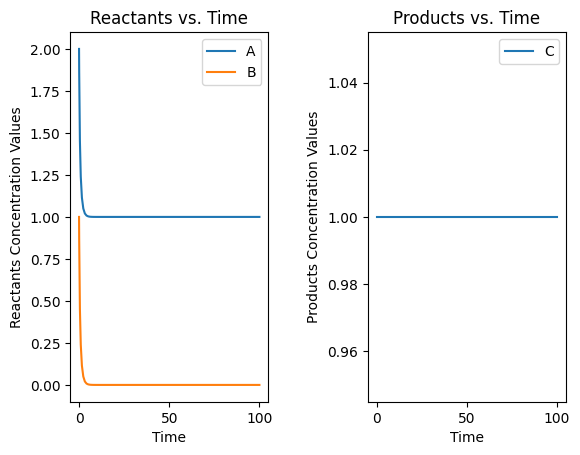

In [ ]:
rxnFlask = ReactionFlask(['A', 'B', 'C'], components = {"Reactants" : ['A', 'B'], "Products" : ['C']})
print(rxnFlask._entityList)

rxnFlask.setInitialCondition([2, 1, 1])

rxnFlask.addReaction(1, reactantsDict = {'A' : 1, 'B' : 1}, productsDict = {})

print(rxnFlask.reactionDeriv(0, rxnFlask._concentrations))

rxnFlask.runSystem(100)

rxnFlask.plotSystem()

['L_N', 'L_A', 'L_E', 'A', 'E', 'D']


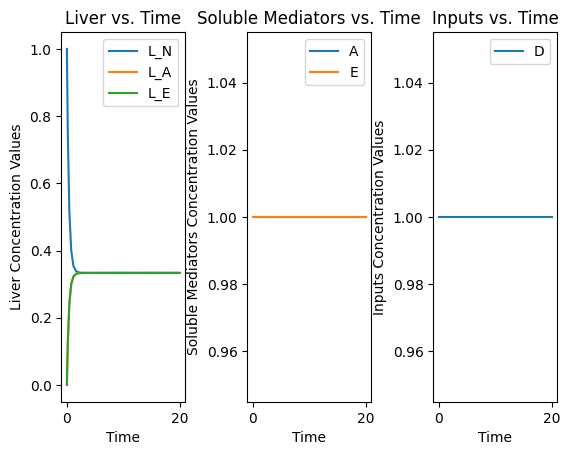

In [ ]:
liverRxnFlask = ReactionFlask(['L_N', 'L_A', 'L_E', 'A', 'E', 'D'], components = {"Liver" : ['L_N', 'L_A', 'L_E'], "Soluble Mediators" : ['A', 'E'], "Inputs" : ['D']})
print(liverRxnFlask._entityList)

liverRxnFlask.setInitialCondition([1, 0, 0, 1, 1, 1])

#Reaction 1: L_N -> L_A
liverRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#Reaction 2: L_A + A -> L_N
liverRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#Reaction 3: L_A + E -> L_A + A
liverRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#Reaction 4: L_E + A -> L_E + E
liverRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#Reaction 5: L_N -> L_E
liverRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#Reaction 6: L_E + E -> L_N
liverRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#Reaction 7: D -> D + A
liverRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#Reaction 8: D -> D + E
liverRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#Reaction 9: A -> naught
liverRxnFlask.addReaction(1, reactantsDict = {'A' : 1}, productsDict = {})

#Reaction 10: E -> naught
liverRxnFlask.addReaction(1, reactantsDict = {'E' : 1}, productsDict = {})

liverRxnFlask.runSystem(20)

liverRxnFlask.plotSystem()

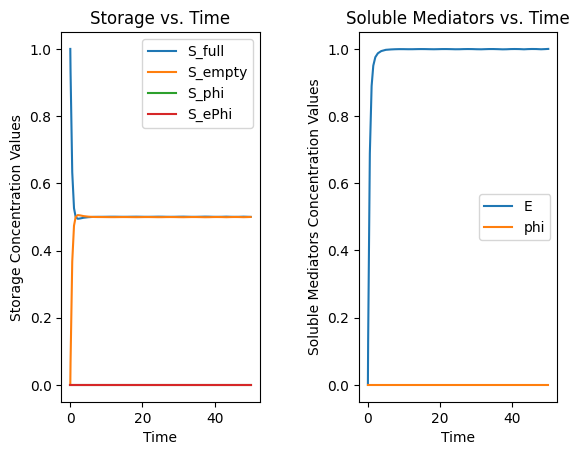

In [ ]:
storageRxnFlask = ReactionFlask(['D','S_full', 'S_empty', 'S_phi', 'S_ePhi', 'E', 'phi'], components = {"Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Soluble Mediators" : ['E', 'phi']})

#Reaction 1: S_full -> S_empty + jE
storageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#Reaction 2: S_empty + jE -> S_full
storageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#Reaction 3: S_full + g * phi -> S_phi
storageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})

#Reaction 4: S_empty + g * phi -> S_ePhi
storageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})

#Reaction 5: S_phi -> S_ePhi + jE
storageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#Reaction 6: S_ePhi -> S_empty
storageRxnFlask.addReaction(1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#Reaction 7: S_phi -> S_full
storageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#Reaction 8: D -> D + E
storageRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#Reaction 9: E -> naught
storageRxnFlask.addReaction(1, reactantsDict = {'E' : 1}, productsDict = {})


storageRxnFlask.setInitialCondition([1, 1, 0, 0, 0, 0, 0])

storageRxnFlask.runSystem(50)

storageRxnFlask.plotSystem()

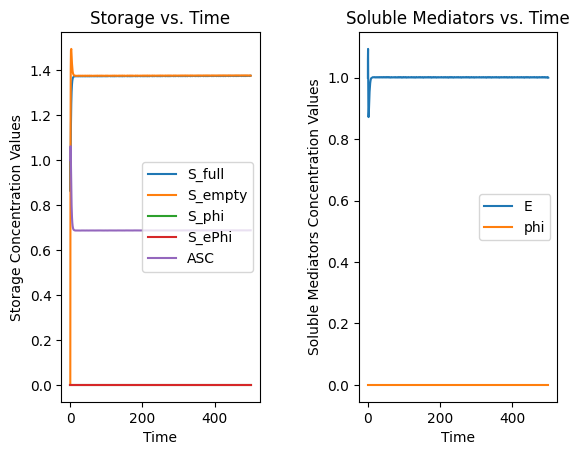

In [ ]:
revampedStorageRxnFlask = ReactionFlask(['D','S_full', 'S_empty', 'S_phi', 'S_ePhi', 'ASC', 'E', 'phi'], components = {"Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi', 'ASC'], "Soluble Mediators" : ['E', 'phi']})

#Reaction 1: S_full -> S_empty + jE
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#Reaction 2: S_empty + jE -> S_full
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#Reaction 3: S_full + g * phi -> S_phi
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})

#Reaction 4: S_empty + g * phi -> S_ePhi
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})

#Reaction 5: S_phi -> S_ePhi + jE
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#Reaction 6: S_ePhi -> S_empty
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#Reaction 7: S_phi -> S_full
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#Reaction 8: D -> D + E
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#Reaction 9: E -> naught
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'E' : 1}, productsDict = {})

#Reaction 10: S_empty -> naught
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1}, productsDict = {})

#Reaction 11: S_ePhi -> naught
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'S_ePhi' : 1}, productsDict = {})

#Reaction 12: ASC + jE -> 2ASC + jE
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'ASC' : 1, 'E' : 1}, productsDict = {'ASC' : 2, 'E' : 1})

#Reaction 13: ASC -> naught
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'ASC' : 1}, productsDict = {})

#Reaction 13: ASC + jE -> 2S_empty + jE
revampedStorageRxnFlask.addReaction(1, reactantsDict = {'ASC' : 1, 'E' : 1}, productsDict = {'S_empty' : 2, 'E' : 1})



revampedStorageRxnFlask.setInitialCondition([1, 1, 0, 0, 0, 1, 1, 0])

revampedStorageRxnFlask.runSystem(500)

revampedStorageRxnFlask.plotSystem()

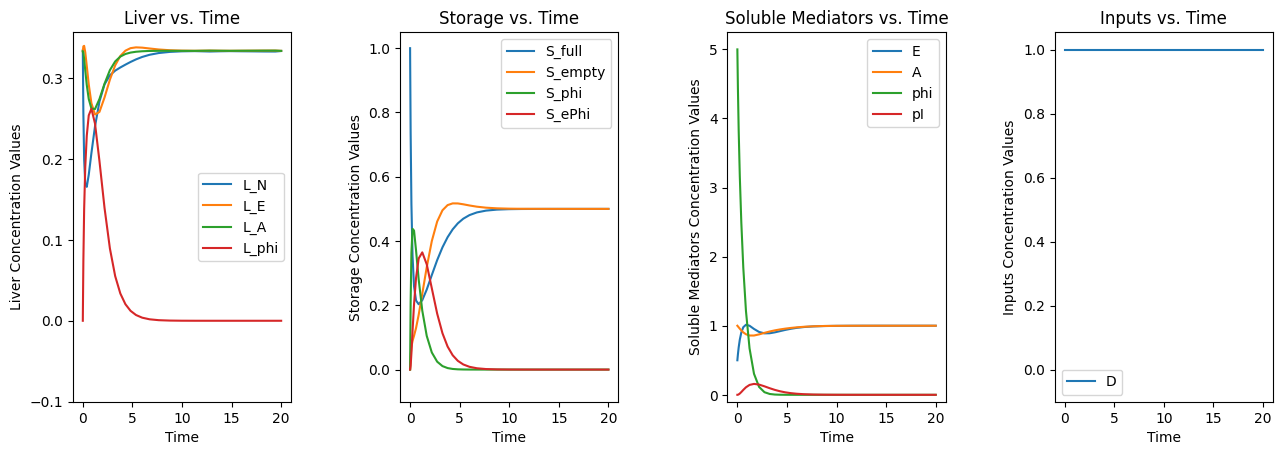

In [ ]:
liverPlusStorageRxnFlask = ReactionFlask(['D', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Inputs" : ['D']})

liverPlusStorageRxnFlask.setInitialCondition([1, 0.334, 0.333, 0.333, 0, 1, 0, 0, 0, 0.5, 1, 5, 0])


#Reaction 1: L_N -> L_A
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#Reaction 2: L_A + A -> L_N
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#Reaction 3: L_A + E -> L_A + A
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#Reaction 4: L_E + A -> L_E + E
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#Reaction 5: L_N -> L_E
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#Reaction 6: L_E + E -> L_N
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#Reaction 7: D -> D + A
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#Reaction 8: D -> D + E
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#Reaction 9: A -> naught
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'A' : 1}, productsDict = {})

#Reaction 10: E -> naught
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'E' : 1}, productsDict = {})

#Reaction 11: S_full -> S_empty + jE
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#Reaction 12: S_empty + jE -> S_full
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#Reaction 13: S_full + g * phi -> S_phi
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})

#Reaction 14: S_empty + g * phi -> S_ePhi
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})

#Reaction 15: S_phi -> S_ePhi + jE
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#Reaction 16: S_ePhi -> S_empty
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#Reaction 17: S_phi -> S_full
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#Reaction 18: phi -> naught
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'phi' : 1}, productsDict = {})

#Reaction 19: L_N + h * phi -> L_phi
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#Reaction 20: L_phi -> L_N
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#Reaction 21: L_phi + A + E -> L_phi + pI
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#Reaction 22: pI -> naught
liverPlusStorageRxnFlask.addReaction(1, reactantsDict = {'pI' : 1}, productsDict = {})

liverPlusStorageRxnFlask.runSystem(20)

liverPlusStorageRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2)

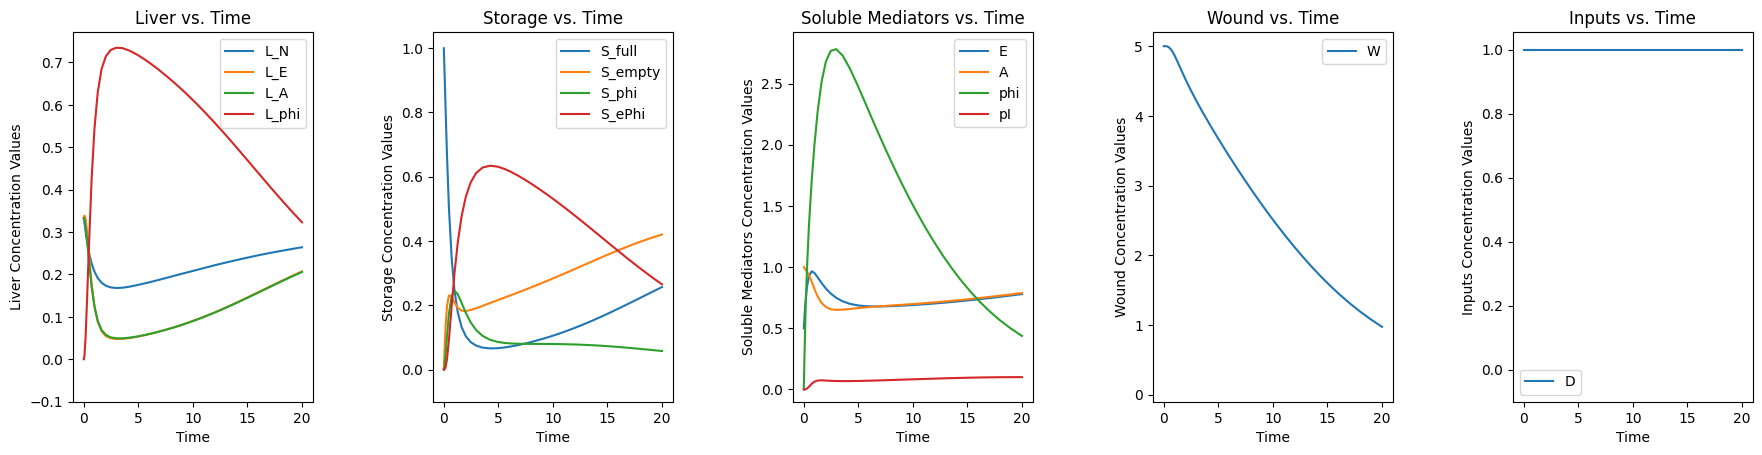

In [ ]:
penultimateRxnFlask = ReactionFlask(['W', 'D', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D']})

penultimateRxnFlask.setInitialCondition([5, 1, 0.334, 0.333, 0.333, 0, 1, 0, 0, 0, 0.5, 1, 0, 0])


#Reaction 1: L_N -> L_A
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#Reaction 2: L_A + A -> L_N
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#Reaction 3: L_A + E -> L_A + A
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#Reaction 4: L_E + A -> L_E + E
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#Reaction 5: L_N -> L_E
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#Reaction 6: L_E + E -> L_N
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#Reaction 7: D -> D + A
penultimateRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#Reaction 8: D -> D + E
penultimateRxnFlask.addReaction(1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#Reaction 9: A -> naught
penultimateRxnFlask.addReaction(1, reactantsDict = {'A' : 1}, productsDict = {})

#Reaction 10: E -> naught
penultimateRxnFlask.addReaction(1, reactantsDict = {'E' : 1}, productsDict = {})

#Reaction 11: S_full -> S_empty + jE
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#Reaction 12: S_empty + jE -> S_full
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#Reaction 13: S_full + g * phi -> S_phi
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})

#Reaction 14: S_empty + g * phi -> S_ePhi
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})

#Reaction 15: S_phi -> S_ePhi + jE
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#Reaction 16: S_ePhi -> S_empty
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#Reaction 17: S_phi -> S_full
penultimateRxnFlask.addReaction(1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#Reaction 18: phi -> naught
penultimateRxnFlask.addReaction(1, reactantsDict = {'phi' : 1}, productsDict = {})

#Reaction 19: L_N + h * phi -> L_phi
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#Reaction 20: L_phi -> L_N
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#Reaction 21: L_phi + A + E -> L_phi + pI
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#Reaction 22: pI -> naught
penultimateRxnFlask.addReaction(1, reactantsDict = {'pI' : 1}, productsDict = {})

#Reaction 23: W -> W + phi
penultimateRxnFlask.addReaction(1, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

#Reaction 24: W + pI -> naught
penultimateRxnFlask.addReaction(1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

#Reaction 25: L_A + phi -> L_phi
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#Reaction 26: L_E + phi -> L_phi
penultimateRxnFlask.addReaction(1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

penultimateRxnFlask.runSystem(20)

penultimateRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

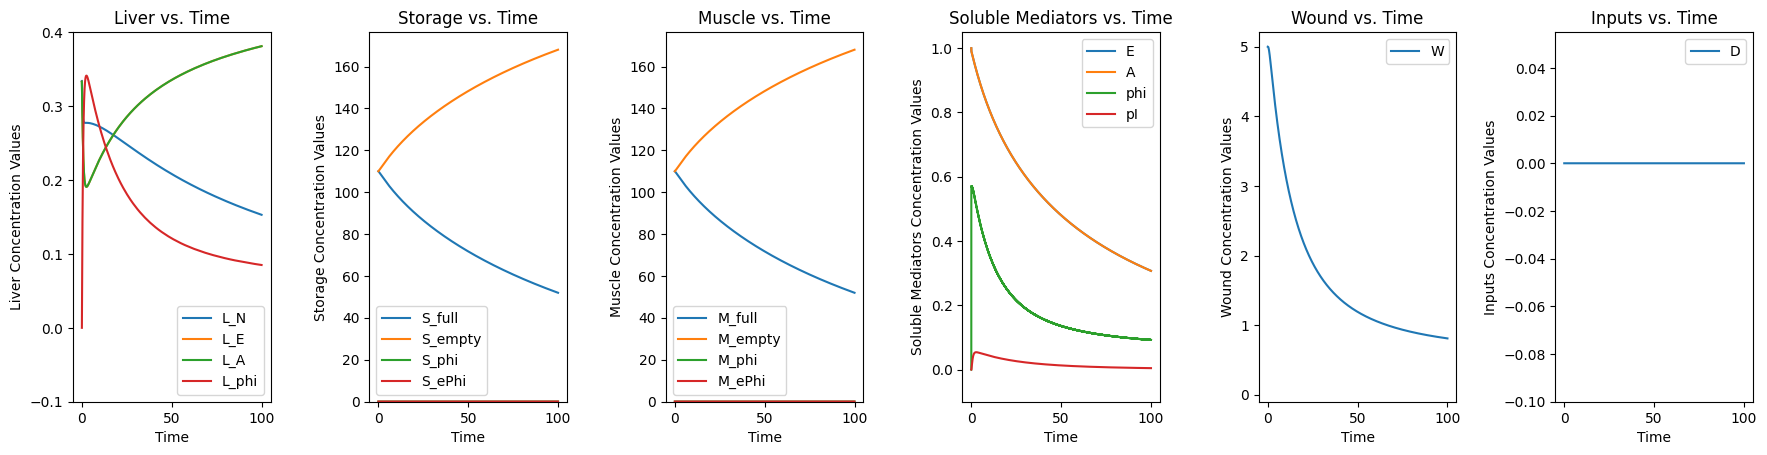

Final value of W: 0.8095732040583559


In [ ]:
ultimateRxnFlask = ReactionFlask(['W', 'D', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D']})

ultimateRxnFlask.setInitialCondition([5, 0, 0.334, 0.333, 0.333, 0, 110, 110, 0, 0, 110, 110, 0, 0, 1, 1, 0, 0])


#
ultimateRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#
ultimateRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#
ultimateRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#
ultimateRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#
ultimateRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

#
ultimateRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

#
ultimateRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

#
ultimateRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

#
ultimateRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

#
ultimateRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#
ultimateRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#
ultimateRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#
ultimateRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

#
ultimateRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
ultimateRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#
ultimateRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#
ultimateRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

#
ultimateRxnFlask.addReaction("Reaction 23: W -> W + phi", 50.5, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

#
ultimateRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

#
ultimateRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
ultimateRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
ultimateRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

#
ultimateRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

#
ultimateRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

#
ultimateRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

#
ultimateRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", 0, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

#
ultimateRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

#
ultimateRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

ultimateRxnFlask.runSystem(100)

ultimateRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

print(f"Final value of W: {ultimateRxnFlask.getFinalValueOfVariable('W')}")

0.2
0.2


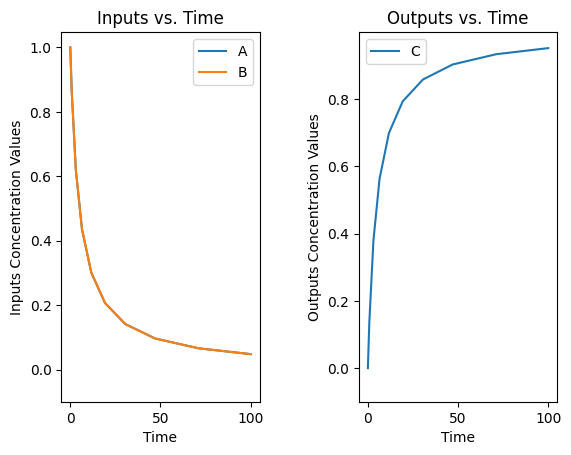

In [ ]:
modifyTestFlask = ReactionFlask(['A', 'B', 'C'], components = {'Inputs' : ['A', 'B'], 'Outputs' : ['C']})

modifyTestFlask.setInitialCondition([1, 1, 0])

modifyTestFlask.addReaction("Addition of A and B", 1, reactantsDict = {'A' : 1, 'B' : 1}, productsDict = {'C' : 1})

modifyTestFlask.modifyReaction("Addition of A and B", newRxnRate = 0.2)
print(modifyTestFlask._reactions["Addition of A and B"]._rxnK)
print(modifyTestFlask._reactions["Addition of A and B"].computeRxnRate(['A', 'B', 'C'], [1, 1, 0]))

modifyTestFlask.runSystem(100)

modifyTestFlask.plotSystem()

In [ ]:
def generateFinalTimepointDataValues(finalTimepoint, numTestPoints, reactionFlask, independentVariables, dependentVariable):
  #1. Create containers for final wound values and input
  # wound healing reaction rate values.

  if(len(independentVariables) == 1):
    finalDependentVariableValues = np.zeros(numTestPoints)

    variableKeys = [key for key in independentVariables]

    variableName = variableKeys[0]

    variableSpecifics = independentVariables[variableName]
    typeOfVariable = variableSpecifics[0]
    variableRange = variableSpecifics[1]

    print(variableRange)

    independentVariableValues = np.linspace(variableRange[0], variableRange[1], numTestPoints)

    #2. Loop
    for k in range(numTestPoints):
      #a. Modify reaction flask's inflammation generation reaction to have new reaction rate
      if typeOfVariable != "Initial Condition":
        if typeOfVariable == "Rate":
          print(independentVariableValues[k])
          reactionFlask.modifyReaction(variableName, newRxnRate = independentVariableValues[k])
      #print(reactionFlask._reactions["Reaction 23: W -> W + phi"]._rxnK)
      reactionFlask.resetInitialCondition()

      #b. Simulate system forward
      reactionFlask.runSystem(finalTimepoint)

      #c. Record final dependent variable value
      finalDependentVariableValues[k] = reactionFlask.getFinalValueOfVariable(dependentVariable)

    if(len(independentVariables) == 2):
      finalDependentVariableValues = np.zeros(numTestPoints, numTestPoints)

      variableNames = []
      variableSpecifics = []
      typeOfVariable = []
      variableRanges = []

      for key in independentVariables:
        variableNames.append(key)
        variableSpecifics.append(independentVariables[variableName])
        typeOfVariable.append(independentVariables[variableName][0])
        variableRange.append(independentVariables[variableName][1])

      print(variableRange)

      independentVariableValues0 = np.linspace(variableRange[0], variableRange[1], numTestPoints)
      independentVariableValues1 = np.linspace()

      #2. Loop
      for j in range(numTestPoints):
        for k in range(numTestPoints):
          #a. Modify reaction flask's inflammation generation reaction to have new reaction rate
          if typeOfVariable != "Initial Condition":
            if typeOfVariable == "Rate":
              print(independentVariableValues[k])
              reactionFlask.modifyReaction(variableName, newRxnRate = independentVariableValues[k])
          #print(reactionFlask._reactions["Reaction 23: W -> W + phi"]._rxnK)
          reactionFlask.resetInitialCondition()

          #b. Simulate system forward
          reactionFlask.runSystem(finalTimepoint)

          #c. Record final dependent variable value
          finalDependentVariableValues[k][j] = reactionFlask.getFinalValueOfVariable(dependentVariable)

    return finalDependentVariableValues, numTestPoints, independentVariableValues

#plotWoundHealingVsInflammation(100, 5, ultimateRxnFlask)

[0.5, 100]
0.5
5.7368421052631575
10.973684210526315
16.210526315789473
21.44736842105263
26.684210526315788
31.921052631578945
37.1578947368421
42.39473684210526
47.63157894736842
52.868421052631575
58.10526315789473
63.34210526315789
68.57894736842104
73.8157894736842
79.05263157894737
84.28947368421052
89.52631578947367
94.76315789473684
100.0
[4.83973247 3.40305281 2.39386565 1.71795664 1.2686513  0.96555851
 0.75576721 0.60602359 0.49555937 0.41121255 0.34441017 0.28936816
 0.24204632 0.19959669 0.16018703 0.12312605 0.08906825 0.05976856
 0.03698877 0.02121715]


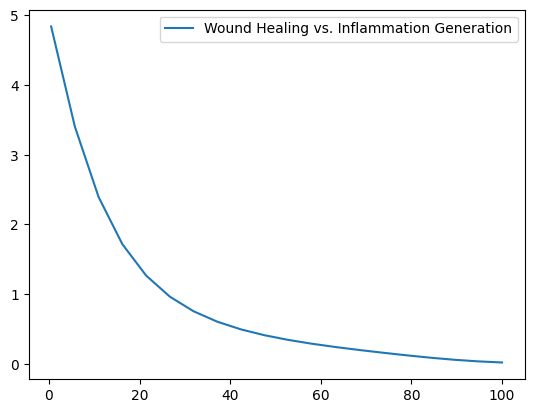

In [ ]:
finalWound = generateFinalTimepointDataValues(100, 20, ultimateRxnFlask, {"Reaction 23: W -> W + phi" : ("Rate", [0.5, 100])}, 'W')

print(finalWound[0])

plt.plot(finalWound[2], finalWound[0], label = "Wound Healing vs. Inflammation Generation")
plt.legend()

plt.show()

In [ ]:
indVal1 = np.array([1, 0, 1])
indVal2 = np.array([0, 1, 0])

independentVariableVals = np.array([[(val1, val2) for val1 in indVal1] for val2 in indVal2])

print(independentVariableVals[0][0])

print(independentVariableVals)

[1 0]
[[[1 0]
  [0 0]
  [1 0]]

 [[1 1]
  [0 1]
  [1 1]]

 [[1 0]
  [0 0]
  [1 0]]]


In [ ]:
inputs = [[1, 1, 1, 1]]

inputList = list(inputs)

results = []

for input in inputList:
  numTestPoints = 10

  initWound = 5

  muscleBreakdown = input[0]
  fatBreakdown = input[1]

  muscleWasting = input[2]
  fatWasting = input[3]

  diet = 0

  experimentalRxnFlask = ReactionFlask(['W', 'D', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D']})


  #
  experimentalRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

  #
  experimentalRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

  #
  experimentalRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

  #
  if fatBreakdown == 1:
    experimentalRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

  #
  if fatBreakdown == 1 or fatWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

  #
  if fatWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
  else:
    #This allows us to keep the inflammatory sink dynamics without changing the fat state
    experimentalRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

  #
  if fatWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
  else:
    #This allows us to keep the inflammatory sink dynamics without changing the fat state
    experimentalRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

  #
  if fatWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

  #
  experimentalRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

  #
  experimentalRxnFlask.addReaction("Reaction 23: W -> W + phi", 1.0, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

  #
  experimentalRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  if muscleBreakdown == 1:
    experimentalRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

  #
  if muscleBreakdown == 1 or muscleWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

  #
  if muscleWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})
  else:
    #This allows for the muscle to still absorb the same amount of inflammation, but without changing state and wasting
    experimentalRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
  #

  if muscleWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" ,1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
  else:
    #This allows for the muscle to still absorb the same amount of inflammation, but without changing state and wasting
    experimentalRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" ,1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

  #
  if muscleWasting == 1:
    experimentalRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

  #
  experimentalRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})


  finalWoundValues = np.zeros((numTestPoints, numTestPoints))
  finalFatValues = np.zeros((numTestPoints, numTestPoints))
  finalMuscleValues = np.zeros((numTestPoints, numTestPoints))


  independentVariableValues0 = np.linspace(1, 100, numTestPoints)
  independentVariableValues1 = np.linspace(10, 100, numTestPoints)

  independentVariableVals = np.array([[(val1, val2) for val1 in independentVariableValues0] for val2 in independentVariableValues1])

  print(independentVariableVals)


  #2. Loop
  for j in range(numTestPoints):
    for k in range(numTestPoints):
      #a. Modify reaction flask's inflammation generation reaction to have new reaction rate
      independentVariablePair = independentVariableVals[j][k]
      experimentalRxnFlask.modifyReaction("Reaction 23: W -> W + phi", newRxnRate = independentVariablePair[0])
      experimentalRxnFlask.setInitialCondition([initWound, diet, 0.334, 0.333, 0.333, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, 1, 1, 0, 0])
      #print(reactionFlask._reactions["Reaction 23: W -> W + phi"]._rxnK)
      experimentalRxnFlask.resetInitialCondition()

      #b. Simulate system forward
      experimentalRxnFlask.runSystem(100)

      #c. Record final dependent variable value
      finalWoundValues[j][k] = experimentalRxnFlask.getFinalValueOfVariable('W')
      finalFatValues[j][k] = experimentalRxnFlask.getFinalValueOfVariable('S_full')
      finalMuscleValues[j][k] = experimentalRxnFlask.getFinalValueOfVariable('M_full')

      results.append([input, (finalWoundValues, finalFatValues, finalMuscleValues)])

      print(f"Obtained {finalWoundValues[j][k]} as final wound result with infl = {independentVariablePair[0]} and weight = {2 * independentVariablePair[1]}")

  #print(finalDependentVariableValues)

[[[  1.  10.]
  [ 12.  10.]
  [ 23.  10.]
  [ 34.  10.]
  [ 45.  10.]
  [ 56.  10.]
  [ 67.  10.]
  [ 78.  10.]
  [ 89.  10.]
  [100.  10.]]

 [[  1.  20.]
  [ 12.  20.]
  [ 23.  20.]
  [ 34.  20.]
  [ 45.  20.]
  [ 56.  20.]
  [ 67.  20.]
  [ 78.  20.]
  [ 89.  20.]
  [100.  20.]]

 [[  1.  30.]
  [ 12.  30.]
  [ 23.  30.]
  [ 34.  30.]
  [ 45.  30.]
  [ 56.  30.]
  [ 67.  30.]
  [ 78.  30.]
  [ 89.  30.]
  [100.  30.]]

 [[  1.  40.]
  [ 12.  40.]
  [ 23.  40.]
  [ 34.  40.]
  [ 45.  40.]
  [ 56.  40.]
  [ 67.  40.]
  [ 78.  40.]
  [ 89.  40.]
  [100.  40.]]

 [[  1.  50.]
  [ 12.  50.]
  [ 23.  50.]
  [ 34.  50.]
  [ 45.  50.]
  [ 56.  50.]
  [ 67.  50.]
  [ 78.  50.]
  [ 89.  50.]
  [100.  50.]]

 [[  1.  60.]
  [ 12.  60.]
  [ 23.  60.]
  [ 34.  60.]
  [ 45.  60.]
  [ 56.  60.]
  [ 67.  60.]
  [ 78.  60.]
  [ 89.  60.]
  [100.  60.]]

 [[  1.  70.]
  [ 12.  70.]
  [ 23.  70.]
  [ 34.  70.]
  [ 45.  70.]
  [ 56.  70.]
  [ 67.  70.]
  [ 78.  70.]
  [ 89.  70.]
  [100.  70.]]

 [[  1

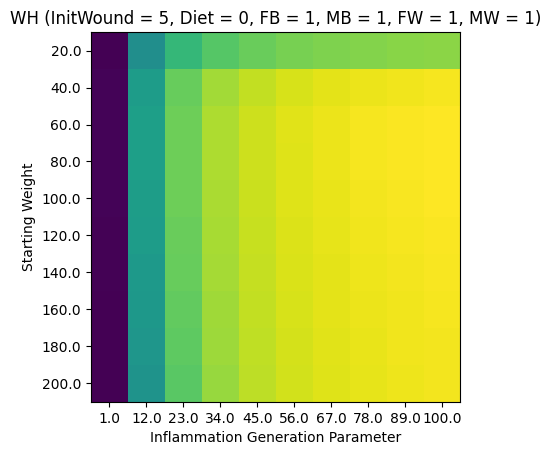

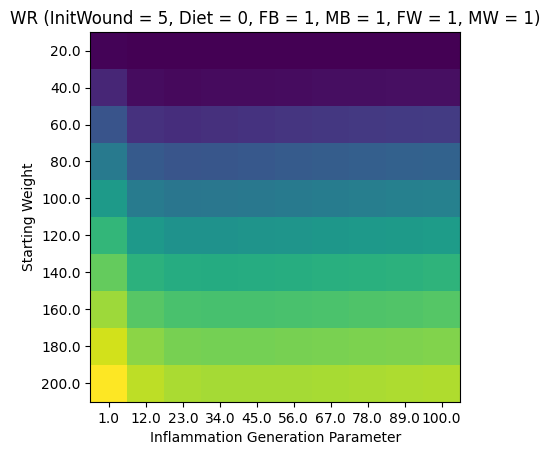

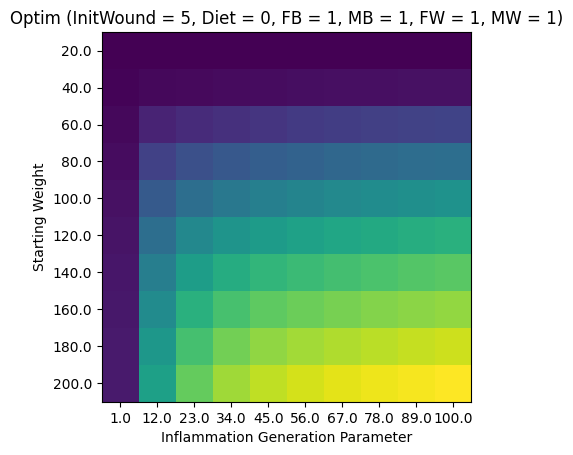

In [ ]:
fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()
fig3, ax3 = plt.subplots()

result = results[0]

input = result[0]

muscleBreakdown = input[0]
fatBreakdown = input[1]

muscleWasting = input[2]
fatWasting = input[3]

resultantValues = result[1]

finalWoundValues = resultantValues[0]
finalFatValues = resultantValues[1]
finalMuscleValues = resultantValues[2]

finalWoundHealingValues = (initWound - finalWoundValues) / initWound

finalWeightValues = finalMuscleValues + finalFatValues
finalWeightProportionValues = np.zeros(np.shape(finalWeightValues))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    rate, weight = independentVariableVals[k][j]
    #print(f"Initial weight = {2 * weight} and final weight = {finalWeightValues[k][j]}")
    finalWeightProportionValues[k][j] = finalWeightValues[k][j] / (weight)

#print(finalWoundHealingValues)

maximumVal = np.max(finalWoundHealingValues)
#print(maximumVal)

for k, values in enumerate(finalWoundHealingValues):
  for j, finalWoundHealingValue in enumerate(values):
    #print(val)
    Found = False
    if finalWoundHealingValue == maximumVal:
      if Found == True:
        print("Something's weird here.")
      else:
        maxValIdx = (k, j)

maximizingInflammationIdx = maxValIdx[0]
maximizingWeightIdx = maxValIdx[1]

finalOptimizationIndexValues = finalWoundHealingValues * finalWeightProportionValues


#print(f"Maximum wound healing (minimum wound size) was obtained with inflammation generation = {independentVariableValues0[maximizingInflammationIdx]}, Initial Weight = {independentVariableValues1[maximizingWeightIdx]}")



ax.imshow(finalWoundHealingValues)

#To plot the dot at the correct (x,y), one sees that the (x,y) in question
# is the center of the minimal square, which is exactly the tuple minValIdx
#ax.plot(maxValIdx[0], maxValIdx[1], 'ro', label = "Maximum Final Wound Healing")
#ax.legend()

ax.set_title(f"WH (InitWound = {initWound}, Diet = {diet}, FB = {fatBreakdown}, MB = {muscleBreakdown}, FW = {fatWasting}, MW = {muscleWasting})")
ax.set_xlabel("Inflammation Generation Parameter")
ax.set_ylabel("Starting Weight")

for k, val in enumerate(independentVariableValues0):
  independentVariableValues0[k] = round(val, 1)

ax.set_xticks(range(numTestPoints), independentVariableValues0)
ax.set_yticks(range(numTestPoints), 2 * independentVariableValues1)


plt.savefig(f"WoundHealingVsInflammationAndInitWeightInitWound={initWound}MF=1Diet={diet}FatBreakdown={fatBreakdown}MuscleBreakdown={muscleBreakdown}.png")



ax2.imshow(finalWeightProportionValues)

#To plot the dot at the correct (x,y), one sees that the (x,y) in question
# is the center of the minimal square, which is exactly the tuple minValIdx
#ax2.plot(minValIdx[0], minValIdx[1], 'ro', label = "Minimum Final Weight")
#ax2.legend()

ax2.set_title(f"WR (InitWound = {initWound}, Diet = {diet}, FB = {fatBreakdown}, MB = {muscleBreakdown}, FW = {fatWasting}, MW = {muscleWasting})")
ax2.set_xlabel("Inflammation Generation Parameter")
ax2.set_ylabel("Starting Weight")

for k, val in enumerate(independentVariableValues0):
  independentVariableValues0[k] = round(val, 1)

ax2.set_xticks(range(numTestPoints), independentVariableValues0)
ax2.set_yticks(range(numTestPoints), 2 * independentVariableValues1)

plt.savefig(f"FinalWeightProportionVsInflammationAndInitWeightInitWound={initWound}MF=1Diet={diet}FatBreakdown={fatBreakdown}MuscleBreakdown={muscleBreakdown}.png")


ax3.imshow(finalOptimizationIndexValues)

#To plot the dot at the correct (x,y), one sees that the (x,y) in question
# is the center of the minimal square, which is exactly the tuple minValIdx
#ax3.plot(maxValIdx[0], maxValIdx[1], 'ro', label = "Maximum Weight-Wound Index")
#ax3.legend()

ax3.set_title(f"Optim (InitWound = {initWound}, Diet = {diet}, FB = {fatBreakdown}, MB = {muscleBreakdown}, FW = {fatWasting}, MW = {muscleWasting})")
ax3.set_xlabel("Inflammation Generation Parameter")
ax3.set_ylabel("Starting Weight")

for k, val in enumerate(independentVariableValues0):
  independentVariableValues0[k] = round(val, 1)

ax3.set_xticks(range(numTestPoints), independentVariableValues0)
ax3.set_yticks(range(numTestPoints), 2 * independentVariableValues1)

plt.savefig(f"OptimizationIndexVsInflammationAndInitWeightInitWound={initWound}MF=1Diet={diet}FatBreakdown={fatBreakdown}MuscleBreakdown={muscleBreakdown}FatWasting.png")

plt.show()

In [ ]:
#For no inflammation-induced wasting
maximumWoundHealingVal = np.max(finalWoundHealingValues)
print(f"Max Wound Healing Value = {maximumWoundHealingVal}")

maximumWeightProportionVal = np.max(finalWeightProportionValues)
print(f"Max Weight Proportion Value = {maximumWeightProportionVal}")

maximumOptimizationIndexVal = np.max(finalOptimizationIndexValues)
print(f"Max Optimization Index Value = {maximumOptimizationIndexVal}")

valuesForComparison = [[input, (maximumWoundHealingVal, maximumWeightProportionVal, maximumOptimizationIndexVal)]]

Max Wound Healing Value = 0.8955163593617735
Max Weight Proportion Value = 0.9339820239825759
Max Optimization Index Value = 0.8051262747806177


In [ ]:
#For w/ inflammation-induced wasting
maximumWoundHealingVal = np.max(finalWoundHealingValues)
print(f"Max Wound Healing Value = {maximumWoundHealingVal}")

maximumWeightProportionVal = np.max(finalWeightProportionValues)
print(f"Max Weight Proportion Value = {maximumWeightProportionVal}")

maximumOptimizationIndexVal = np.max(finalOptimizationIndexValues)
print(f"Max Optimization Index Value = {maximumOptimizationIndexVal}")

valuesForComparison.append([input, (maximumWoundHealingVal, maximumWeightProportionVal, maximumOptimizationIndexVal)])

Max Wound Healing Value = 0.9872450433342979
Max Weight Proportion Value = 0.9250870150337411
Max Optimization Index Value = 0.7902703510980342


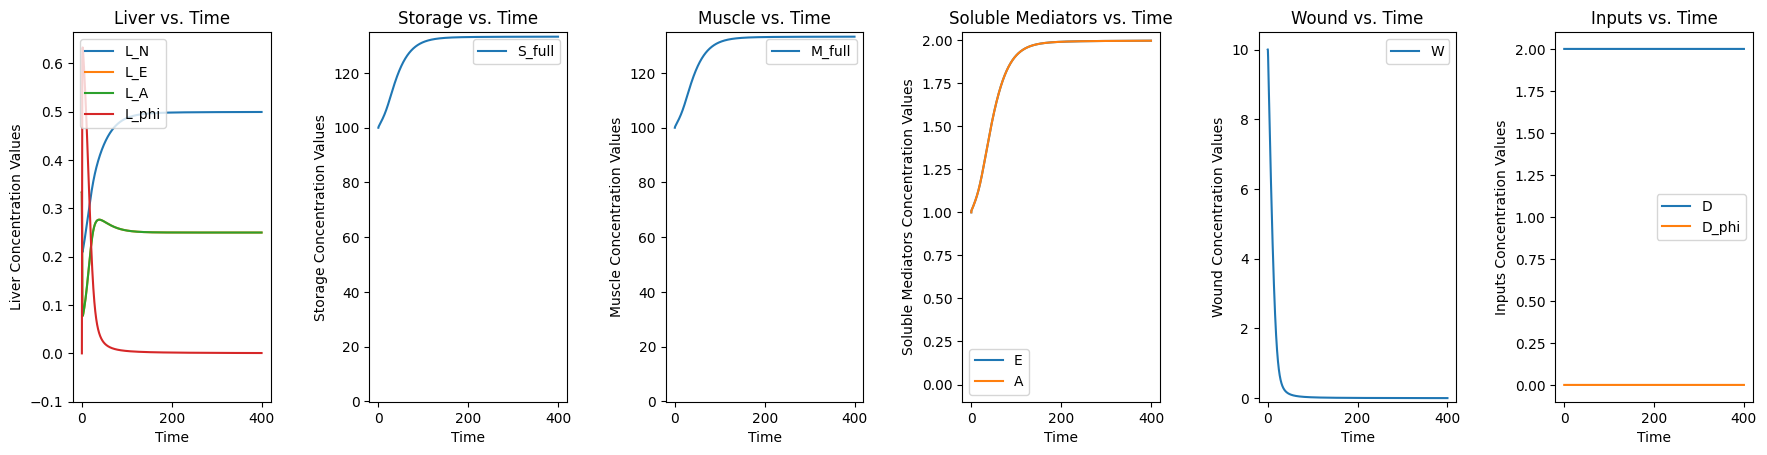

-1.173913043478261
Final value of W: 0.003847919592534181


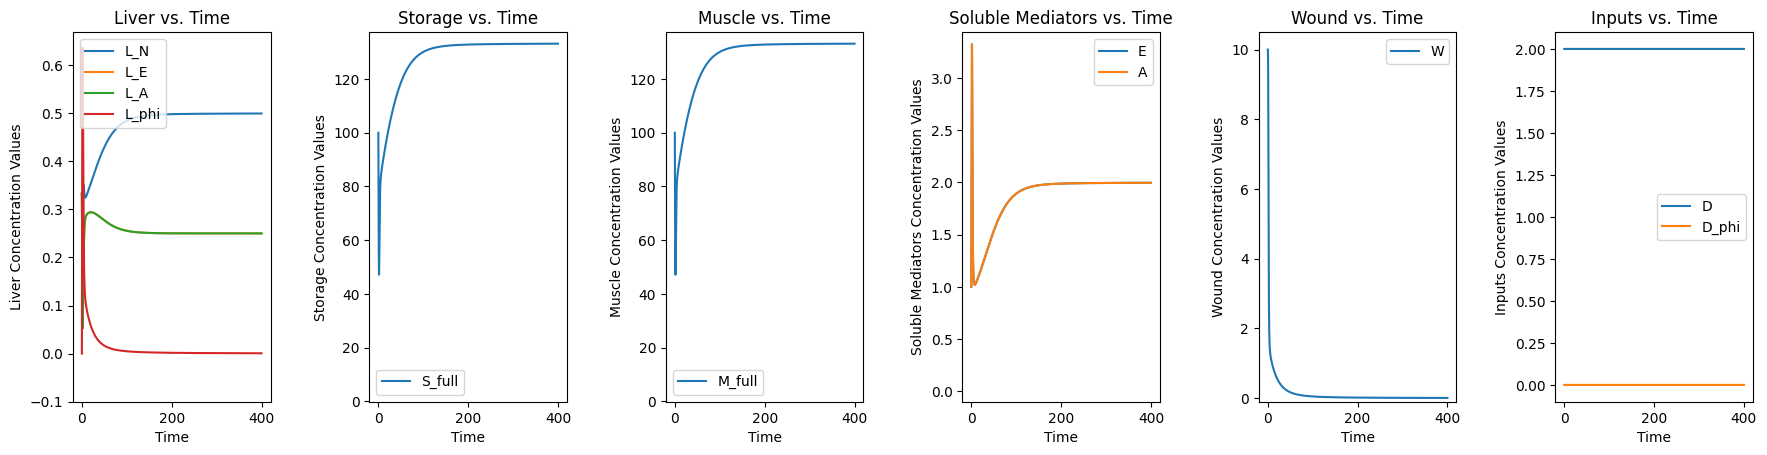

-0.025569416262026422
Final value of W: 0.007725441355318759


In [ ]:
initWound = 10

diet = 2

anorexiaRxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full'], "Muscle" : ['M_full'], "Soluble Mediators" : ['E', 'A'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

anorexiaRxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 100, 100, 0, 0, 100, 100, 0, 0, 1, 1, 0, 0])

timeValuesList = []

woundValsVsTime = []
weightValsVsTime = []
nutrientsVsTime = []

for x in range(2):

  if(x == 0):
    inflammationInducedWasting = False
  elif (x == 1):
    inflammationInducedWasting = True

  #
  anorexiaRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
  else:
    #This allows S_full to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
  else:
    #This allows S_empty to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

  if inflammationInducedWasting == True:
    fatWastingReactionRate = 1
  else:
    fatWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", fatWastingReactionRate, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 23: W -> W + phi", 75, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
  else:
    #This allows M_full to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
  else:
    #This allows M_empty to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

  if inflammationInducedWasting == True:
    muscleWastingReactionRate = 1
  else:
    muscleWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", muscleWastingReactionRate, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

  #
  #anorexiaRxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

  #
  #anorexiaRxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})


  anorexiaRxnFlask.runSystem(400)

  anorexiaRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

  timeValues = anorexiaRxnFlask.latestSimulationOutput["t"]

  localWeightDropValues = (46 * 2 - anorexiaRxnFlask.latestSimulationOutput["y"][7] - anorexiaRxnFlask.latestSimulationOutput["y"][11])

  print(np.max(localWeightDropValues) / (46 * 2))

  #print(anorexiaRxnFlask.latestSimulationOutput["t"])

  print(f"Final value of W: {anorexiaRxnFlask.getFinalValueOfVariable('W')}")

  anorexiaRxnFlask.resetInitialCondition()

  timeValuesList.append(timeValues)
  woundValsVsTime.append(anorexiaRxnFlask.latestSimulationOutput["y"][0])
  weightValsVsTime.append(2 * anorexiaRxnFlask.latestSimulationOutput["y"][7])
  nutrientsVsTime.append(anorexiaRxnFlask.latestSimulationOutput["y"][16])

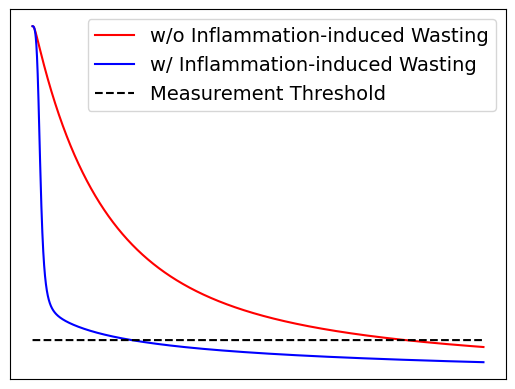

In [ ]:
#Weight is twice the storage value since muscle and storage are
#being used equally

figure1, axis1 = plt.subplots()

axis1.plot(timeValuesList[0], woundValsVsTime[0], label = "w/o Inflammation-induced Wasting", color = 'r')
#plt.fill_between(timeValuesList[0], [100 for k in range(len(timeValuesList[0]))], woundValsVsTime[0], color = 'r')

axis1.plot(timeValuesList[1], woundValsVsTime[1], label = "w/ Inflammation-induced Wasting", color = 'b')
#plt.fill_between(timeValuesList[1], [100 for k in range(len(timeValuesList[1]))], woundValsVsTime[1], color = 'b')

axis1.plot(timeValuesList[0], [1 for k in range(len(timeValuesList[0]))], 'k--', label = "Measurement Threshold")

axis1.set_xticks([])
axis1.set_yticks([])

axis1.legend(fontsize = 14)
plt.savefig("WoundHealingVsTimeBetweenTwoTreatments.png")
plt.show()

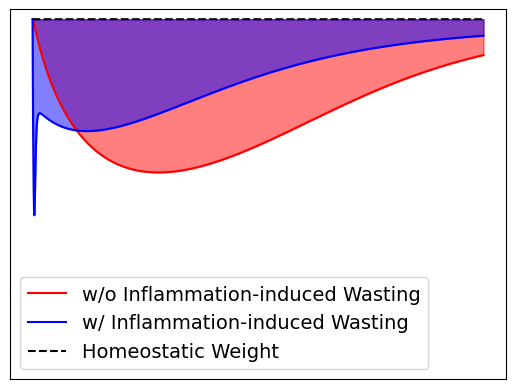

In [ ]:
figure2, axis2 = plt.subplots()

axis2.plot(timeValuesList[0], weightValsVsTime[0], label = "w/o Inflammation-induced Wasting", color = 'r')
axis2.fill_between(timeValuesList[0], [200 for k in range(len(timeValuesList[0]))], weightValsVsTime[0], color = 'r', alpha = 0.5)

axis2.plot(timeValuesList[1], weightValsVsTime[1], label = "w/ Inflammation-induced Wasting", color = 'b')
axis2.fill_between(timeValuesList[1], [200 for k in range(len(timeValuesList[1]))], weightValsVsTime[1], color = 'b', alpha = 0.5)

axis2.plot(timeValuesList[0], [200 for k in range(len(timeValuesList[0]))], 'k--', label = "Homeostatic Weight")

axis2.set_ylim(bottom = -0.01)

axis2.set_xticks([])
axis2.set_yticks([])

axis2.legend(fontsize = 14)
plt.savefig("WeightVsTimeBetweenTwoTreatments.png")
plt.show()

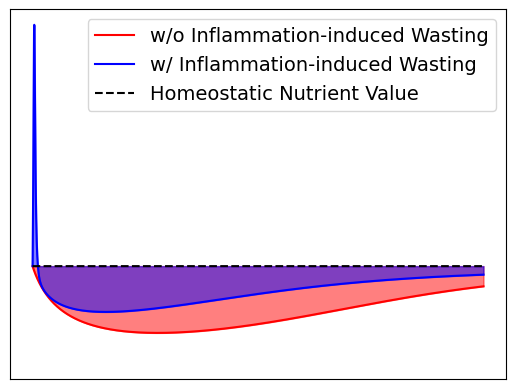

In [ ]:
figure3, axis3 = plt.subplots()

axis3.plot(timeValuesList[0], nutrientsVsTime[0], label = "w/o Inflammation-induced Wasting", color = 'r')
axis3.fill_between(timeValuesList[0], [1 for k in range(len(timeValuesList[0]))], nutrientsVsTime[0], color = 'r', alpha = 0.5)

axis3.plot(timeValuesList[1], nutrientsVsTime[1], label = "w/ Inflammation-induced Wasting", color = 'b')
axis3.fill_between(timeValuesList[1], [1 for k in range(len(timeValuesList[1]))], nutrientsVsTime[1], color = 'b', alpha = 0.5)

axis3.plot(timeValuesList[0], [1 for k in range(len(timeValuesList[0]))], 'k--', label = "Homeostatic Nutrient Value")

axis3.set_ylim(bottom = -0.01)

axis3.set_xticks([])
axis3.set_yticks([])

axis3.legend(fontsize = 14)
plt.savefig("AminoAcidsVsTimeBetweenTwoTreatments.png")
plt.show()

In [ ]:
simulationOutputObjects = []
numTestPoints = 20

for c in range(len([False, True])):
  conditionLevelSimulationOutputs = []

  independentVariableValues0 = np.linspace(10, 100, numTestPoints)
  independentVariableValues1 = np.array([80])

  independentVariableVals = np.array([[(val1, val2) for val1 in independentVariableValues0] for val2 in independentVariableValues1])

  print(independentVariableVals)

  initWound = 5
  diet = 1

  anorexiaRxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

  anorexiaRxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 50, 50, 0, 0, 50, 50, 0, 0, 1, 1, 0, 0])

  if(c == 0):
    inflammationInducedWasting = False
  elif (c == 1):
    inflammationInducedWasting = True

  #
  anorexiaRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
  else:
    #This allows S_full to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
  else:
    #This allows S_empty to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

  if inflammationInducedWasting == True:
    fatWastingReactionRate = 1
  else:
    fatWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", fatWastingReactionRate, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 23: W -> W + phi", 50.5, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
  else:
    #This allows M_full to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
  else:
    #This allows M_empty to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

  if inflammationInducedWasting == True:
    muscleWastingReactionRate = 1
  else:
    muscleWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", muscleWastingReactionRate, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})

  '''
  anorexiaRxnFlask.runSystem(250)

  anorexiaRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

  timeValues = anorexiaRxnFlask.latestSimulationOutput["t"]

  print(anorexiaRxnFlask.latestSimulationOutput["t"])

  print(f"Final value of W: {anorexiaRxnFlask.getFinalValueOfVariable('W')}")'''



  #2. Loop
  for j in range(len(independentVariableValues1)):
    rowLevelSimulationOutputs = []
    for k in range(numTestPoints):
      #a. Modify reaction flask's inflammation generation reaction to have new reaction rate
      independentVariablePair = independentVariableVals[j][k]
      anorexiaRxnFlask.modifyReaction("Reaction 23: W -> W + phi", newRxnRate = independentVariablePair[0])
      anorexiaRxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, 1, 1, 0, 0])
      #print(reactionFlask._reactions["Reaction 23: W -> W + phi"]._rxnK)
      anorexiaRxnFlask.resetInitialCondition()

      #b. Simulate system forward
      anorexiaRxnFlask.runSystem(400)

      #c. Record final dependent variable value
      rowLevelSimulationOutputs.append([independentVariablePair, anorexiaRxnFlask.latestSimulationOutput])

      #print(f"Obtained {finalWoundValues[j][k]} as final wound result with infl = {independentVariablePair[0]} and weight = {2 * independentVariablePair[1]}")
    conditionLevelSimulationOutputs.append(rowLevelSimulationOutputs)
  simulationOutputObjects.append(conditionLevelSimulationOutputs)

[[[ 10.          80.        ]
  [ 14.73684211  80.        ]
  [ 19.47368421  80.        ]
  [ 24.21052632  80.        ]
  [ 28.94736842  80.        ]
  [ 33.68421053  80.        ]
  [ 38.42105263  80.        ]
  [ 43.15789474  80.        ]
  [ 47.89473684  80.        ]
  [ 52.63157895  80.        ]
  [ 57.36842105  80.        ]
  [ 62.10526316  80.        ]
  [ 66.84210526  80.        ]
  [ 71.57894737  80.        ]
  [ 76.31578947  80.        ]
  [ 81.05263158  80.        ]
  [ 85.78947368  80.        ]
  [ 90.52631579  80.        ]
  [ 95.26315789  80.        ]
  [100.          80.        ]]]
[[[ 10.          80.        ]
  [ 14.73684211  80.        ]
  [ 19.47368421  80.        ]
  [ 24.21052632  80.        ]
  [ 28.94736842  80.        ]
  [ 33.68421053  80.        ]
  [ 38.42105263  80.        ]
  [ 43.15789474  80.        ]
  [ 47.89473684  80.        ]
  [ 52.63157895  80.        ]
  [ 57.36842105  80.        ]
  [ 62.10526316  80.        ]
  [ 66.84210526  80.        ]
  [ 71.5

In [ ]:
finalWoundValues = anorexiaRxnFlask.latestSimulationOutput["y"][0]

finalWeightDropVals = 110 - anorexiaRxnFlask.latestSimulationOutput["y"][7]

#1. Get boolean mask of finalWoundValues, <= 10% of initWound
def calculateWoundHealingTime(timeValues, woundValues, threshold):
  #initWound = woundValues[0], correct?
  healedWound = np.where(woundValues <= threshold * woundValues[0])[0]
  try:
    healedWoundIndex = healedWound[0]
  except(IndexError):
    #This ensures that, if the wound never was healed to the threshold, it
    #automatically reports the longest time
    return timeValues[-1]

  healedWoundTime = timeValues[healedWoundIndex]
  return healedWoundTime



In [ ]:
def riemannSum(timeValues, functionValues, side):
  #1. Define summing variable and begin loop
  areaSum = 0
  for k in range(len(timeValues) - 1):
    dt = timeValues[k + 1] - timeValues[k]

    if side == "left":
      height = functionValues[k]
    elif side == "right":
      height = functionValues[k + 1]
    else:
      print("You've made a mistake in entering the side that you would like to approximate the value of the function from. Valid choices are 'left' and 'right'")

    areaSum += height * dt

  return areaSum


In [ ]:
def calculateMetricsOnSimulation(independentVariablePair, simulationOutput):
  timeValues = simulationOutput["t"]
  woundValues = simulationOutput["y"][0]
  fatValues = simulationOutput["y"][7]
  muscleValues = simulationOutput["y"][11]
  aminoAcidLevels = simulationOutput["y"][16]

  startingWeight = independentVariablePair[1] * 2

  weightDropValues = startingWeight - (fatValues + muscleValues)
  weightDropValues = weightDropValues / startingWeight

  maxWeightDrop = np.max(weightDropValues)

  #When diet = 1, the steady state value of amino acid level will be 1
  aminoAcidDropValues = 1 - aminoAcidLevels

  maxAminoAcidDrop = np.max(aminoAcidDropValues)

  return (calculateWoundHealingTime(timeValues, woundValues, threshold = 0.1),
          riemannSum(timeValues, weightDropValues, "left"),
          maxWeightDrop,
          riemannSum(timeValues, aminoAcidDropValues, "left"),
          maxAminoAcidDrop)


In [ ]:
woundHealingTimeValues = np.zeros((len([False, True]), 1, numTestPoints))
weightDropIntegralVals = np.zeros((len([False, True]), 1, numTestPoints))
maxWeightDropVals = np.zeros((len([False, True]), 1, numTestPoints))
aminoAcidDropIntegralVals = np.zeros((len([False, True]), 1, numTestPoints))
maxAminoAcidDropVals = np.zeros((len([False, True]), 1, numTestPoints))

for c in range(len([False, True])):
  for j in range(1):
    for k in range(numTestPoints):
      independentVariablePair, simulationOutput = simulationOutputObjects[c][j][k]
      (woundHealingTimeValues[c][j][k],
       weightDropIntegralVals[c][j][k],
       maxWeightDropVals[c][j][k],
       aminoAcidDropIntegralVals[c][j][k],
       maxAminoAcidDropVals[c][j][k]) = calculateMetricsOnSimulation(independentVariablePair, simulationOutput)

print(maxWeightDropVals)

[[[0.02667735 0.03201393 0.03603459 0.03924493 0.04190622 0.04417148
   0.04613804 0.04787163 0.04941871 0.05081329 0.05208101 0.05324165
   0.0543108  0.05530091 0.05622214 0.05708282 0.05788992 0.05864926
   0.05936582 0.06004384]]

 [[0.10458391 0.13634752 0.17740995 0.21874532 0.25977467 0.30027354
   0.34011068 0.37919706 0.41746998 0.45487676 0.49133099 0.52695295
   0.56159655 0.59531748 0.6279811  0.65973796 0.69034563 0.72018588
   0.74877942 0.77604612]]]


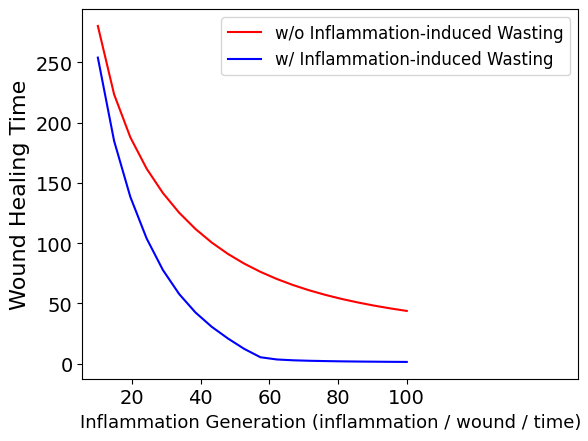

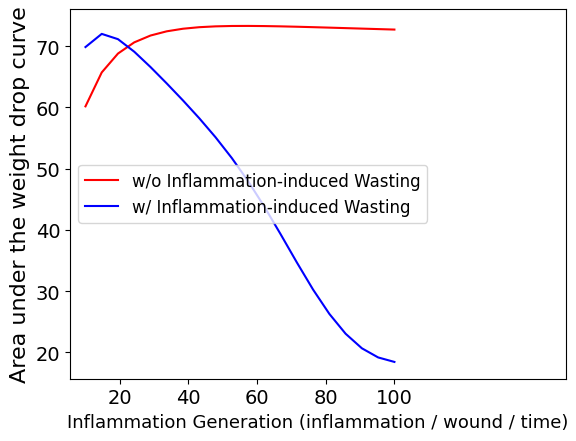

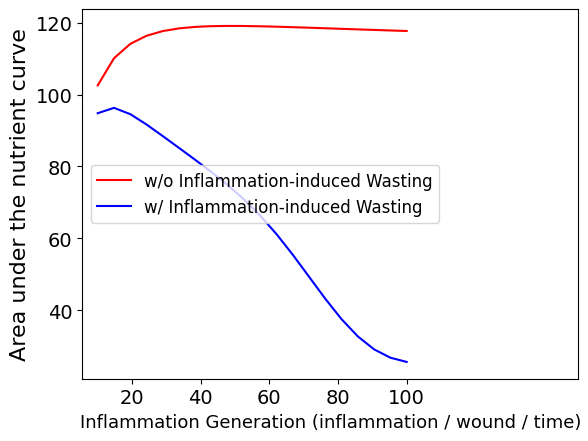

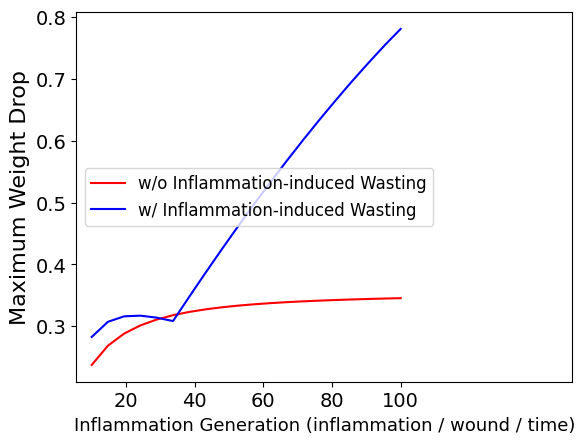

[np.float64(30.209989023128117), np.float64(3.9405088381563926), np.float64(4.598002348975732), np.float64(2.2589199021860527)]


In [ ]:
finalRatios = []

figTree1, axe1 = plt.subplots()

axe1.plot(np.linspace(10, 100, numTestPoints), woundHealingTimeValues[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe1.plot(np.linspace(10, 100, numTestPoints), woundHealingTimeValues[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe1.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe1.set_ylabel("Wound Healing Time", fontsize = 16)
axe1.set_xlim(right = 150)

axe1.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe1.set_yticks([0, 50, 100, 150, 200, 250], labels = [0, 50, 100, 150, 200, 250], fontsize = 14)

axe1.legend(fontsize = 12)

finalRatios.append(woundHealingTimeValues[0][0][-1] / woundHealingTimeValues[1][0][-1])

plt.savefig("WoundHealingTimeVsInflammationGenerationForStartingWeight=160.png")

figTree2, axe2 = plt.subplots()

axe2.plot(np.linspace(10, 100, numTestPoints), weightDropIntegralVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe2.plot(np.linspace(10, 100, numTestPoints), weightDropIntegralVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe2.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe2.set_ylabel("Area under the weight drop curve", fontsize = 16)

axe2.set_xlim(right = 150)
axe2.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe2.set_yticks([20, 30, 40, 50, 60, 70], labels = [20, 30, 40, 50, 60, 70], fontsize = 14)
axe2.legend(loc = "center left", fontsize = 12)

finalRatios.append(weightDropIntegralVals[0][0][-1] / weightDropIntegralVals[1][0][-1])

plt.savefig("WeightDropIntegralVsInflammationGenerationForStartingWeight=160.png")

figTree3, axe3 = plt.subplots()
axe3.plot(np.linspace(10, 100, numTestPoints), aminoAcidDropIntegralVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe3.plot(np.linspace(10, 100, numTestPoints), aminoAcidDropIntegralVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")
axe3.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe3.set_ylabel("Area under the nutrient curve", fontsize = 16)

axe3.set_xlim(right = 150)
axe3.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe3.set_yticks([40, 60, 80, 100, 120], labels = [40, 60, 80, 100, 120], fontsize = 14)
axe3.legend(loc = "center left", fontsize = 12)

finalRatios.append(aminoAcidDropIntegralVals[0][0][-1] / aminoAcidDropIntegralVals[1][0][-1])

plt.savefig("NutrientIntegralVsInflammationGenerationForStartingWeight=160.png")

figTree4, axe4 = plt.subplots()
axe4.plot(np.linspace(10, 100, numTestPoints), maxWeightDropVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe4.plot(np.linspace(10, 100, numTestPoints), maxWeightDropVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe4.set_xlim(right = 150)
axe4.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe4.set_ylabel("Maximum Weight Drop", fontsize = 16)

axe4.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe4.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8], labels = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8], fontsize = 14)
axe4.legend(fontsize = 12, loc = "center left")

finalRatios.append(maxWeightDropVals[1][0][-1] / maxWeightDropVals[0][0][-1])

plt.savefig("MaxWeightDropVsInflammationGenerationForStartingWeight=160.png")
#How should I display this data??
#Could I pick one particular representative sample?
#I suppose that could be useful, but then I would just have to report the calculated metrics in the text and not in graphical form.
#What's wrong with this format? Let me put a title on it and some axes and see how it looks

#plt.title("Wound Healing Metrics vs. Inflammation Generation")

#plt.legend()
plt.show()

print(finalRatios)

In [ ]:
woundHealingTimeValues = np.zeros((len([False, True]), numTestPoints, numTestPoints))
weightDropIntegralVals = np.zeros((len([False, True]), numTestPoints, numTestPoints))
maxWeightDropVals = np.zeros((len([False, True]), numTestPoints, numTestPoints))
aminoAcidDropIntegralVals = np.zeros((len([False, True]), numTestPoints, numTestPoints))
maxAminoAcidDropVals = np.zeros((len([False, True]), numTestPoints, numTestPoints))

for c in range(len([False, True])):
  for j in range(numTestPoints):
    for k in range(numTestPoints):
      independentVariablePair, simulationOutput = simulationOutputObjects[c][j][k]
      (woundHealingTimeValues[c][j][k],
       weightDropIntegralVals[c][j][k],
       maxWeightDropVals[c][j][k],
       aminoAcidDropIntegralVals[c][j][k],
       maxAminoAcidDropVals[c][j][k]) = calculateMetricsOnSimulation(independentVariablePair, simulationOutput)

print(maxWeightDropVals[0])
print(simulationOutputObjects[1][2][5][0])

IndexError: list index out of range

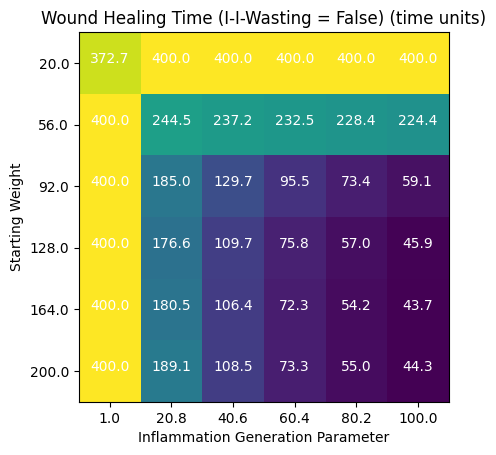

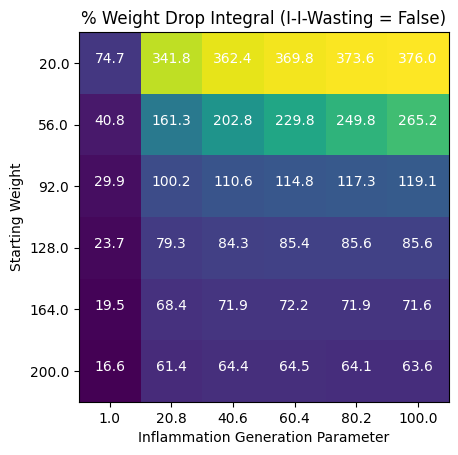

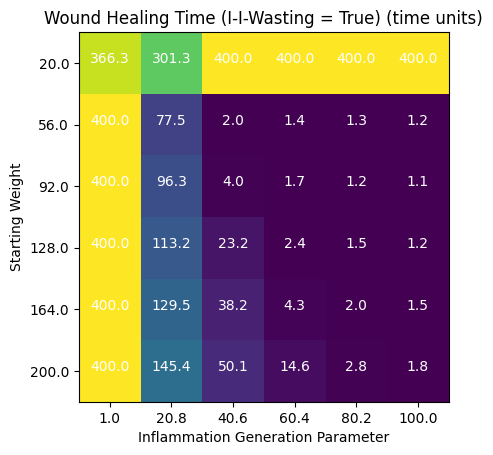

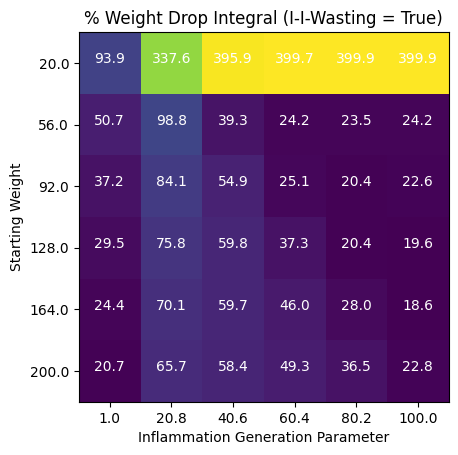

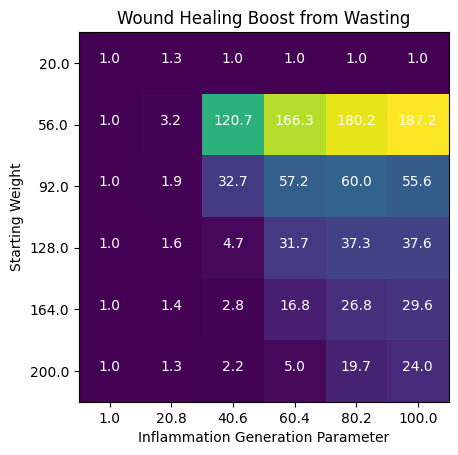

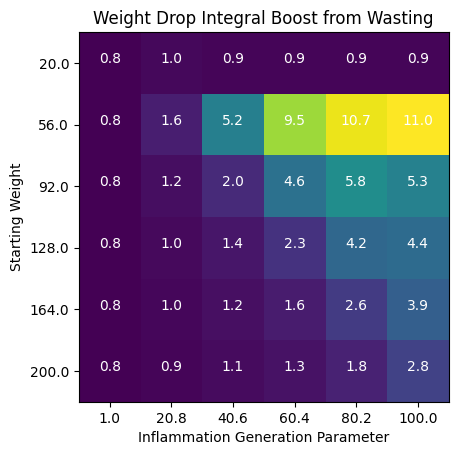

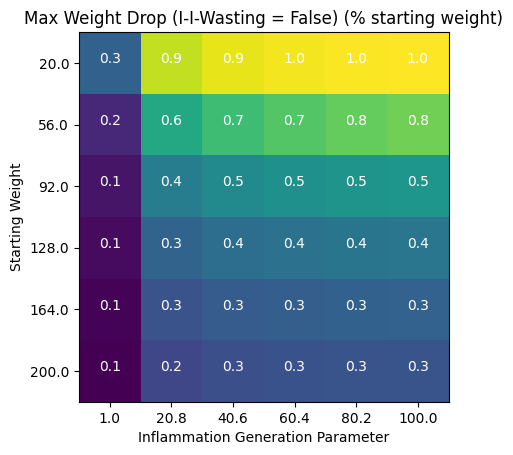

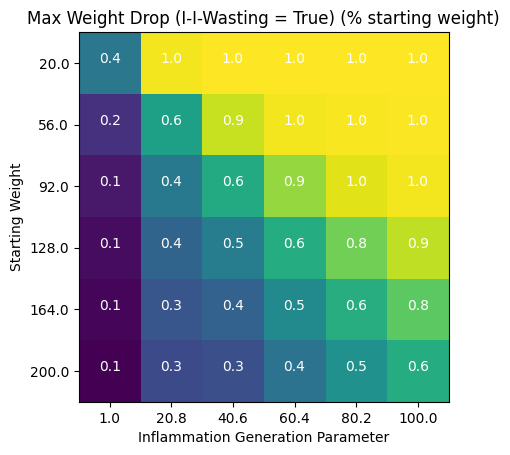

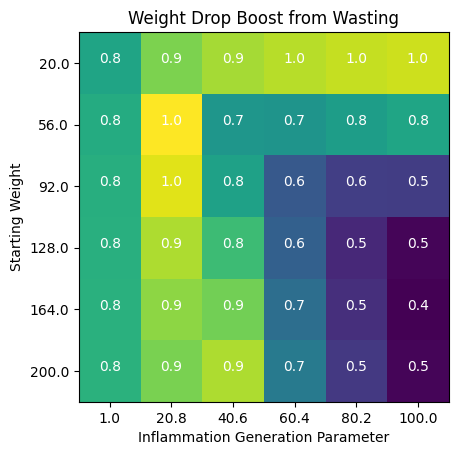

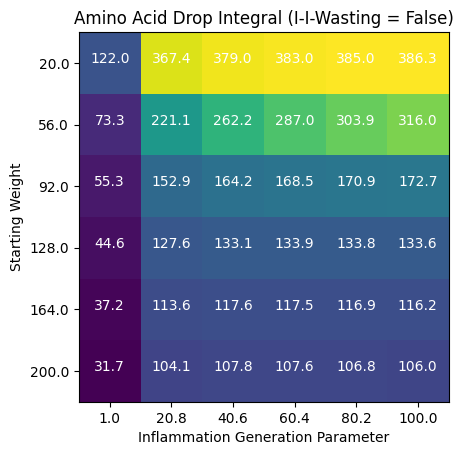

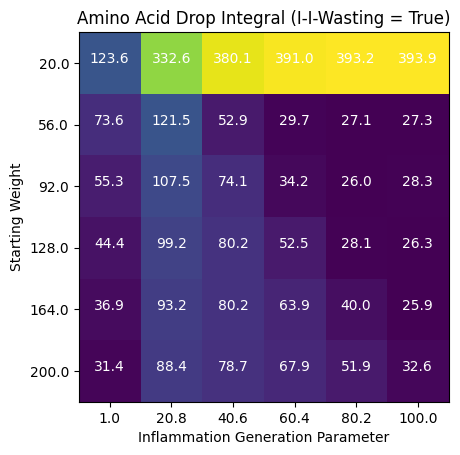

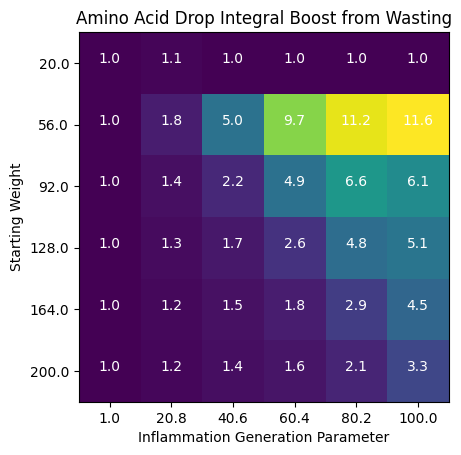

In [ ]:
fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()
fig3, ax3 = plt.subplots()
fig4, ax4 = plt.subplots()
fig5, ax5 = plt.subplots()
fig6, ax6 = plt.subplots()
fig7, ax7 = plt.subplots()
fig8, ax8 = plt.subplots()
fig9, ax9 = plt.subplots()
fig10, ax10 = plt.subplots()
fig11, ax11 = plt.subplots()
fig12, ax12 = plt.subplots()


inflammationTickLabels = np.linspace(1, 100, numTestPoints)

for k, tickVal in enumerate(inflammationTickLabels):
  inflammationTickLabels[k] = round(tickVal, 1)

ax.imshow(woundHealingTimeValues[0])

ax.set_title("Wound Healing Time (I-I-Wasting = False) (time units)")
ax.set_xlabel("Inflammation Generation Parameter")
ax.set_ylabel("Starting Weight")

ax.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax.text(j, k, round(woundHealingTimeValues[0][k][j], 1), ha = "center", c = '1', figure = fig)

plt.savefig("WoundHealingTimevsInflammationGenerationParameterStartingWeightInitWound=5Diet=IIA.png")

ax2.imshow(weightDropIntegralVals[0])

ax2.set_title("% Weight Drop Integral (I-I-Wasting = False)")
ax2.set_xlabel("Inflammation Generation Parameter")
ax2.set_ylabel("Starting Weight")

ax2.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax2.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax2.text(j, k, round(weightDropIntegralVals[0][k][j], 1), ha = "center", c = '1', figure = fig2)

plt.savefig("PercentWeightDropIntegralVsInflammationGenerationParameterStartingWeightInitWound=5.png")

ax3.imshow(woundHealingTimeValues[1])

ax3.set_title("Wound Healing Time (I-I-Wasting = True) (time units)")
ax3.set_xlabel("Inflammation Generation Parameter")
ax3.set_ylabel("Starting Weight")

ax3.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax3.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax3.text(j, k, round(woundHealingTimeValues[1][k][j], 1), ha = "center", c = '1', figure = fig3)

plt.savefig("WoundHealingTimevsInflammationGenerationParameterStartingWeightInitWound=5Diet=IIA.png")

ax4.imshow(weightDropIntegralVals[1])

ax4.set_title("% Weight Drop Integral (I-I-Wasting = True)")
ax4.set_xlabel("Inflammation Generation Parameter")
ax4.set_ylabel("Starting Weight")

ax4.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax4.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax4.text(j, k, round(weightDropIntegralVals[1][k][j], 1), ha = "center", c = '1', figure = fig4)

plt.savefig("PercentWeightDropIntegralVsInflammationGenerationParameterStartingWeightInitWound=5.png")

#By taking the dividend of wound healing time without the wasting and the wound healing time with it, one obtains the speedup factor

woundHealingBoost = woundHealingTimeValues[0] / woundHealingTimeValues[1]
ax5.imshow(woundHealingBoost)

ax5.set_title("Wound Healing Boost from Wasting")
ax5.set_xlabel("Inflammation Generation Parameter")
ax5.set_ylabel("Starting Weight")

ax5.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax5.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax5.text(j, k, round(woundHealingBoost[k][j], 1), ha = "center", c = '1', figure = fig5)

plt.savefig("WoundHealingBoostfromWastingVsInflammationGenerationParameterStartingWeightInitWound=5.png")

weightDropIntegralBoost = weightDropIntegralVals[0] / weightDropIntegralVals[1]
ax6.imshow(weightDropIntegralBoost)

ax6.set_title("Weight Drop Integral Boost from Wasting")
ax6.set_xlabel("Inflammation Generation Parameter")
ax6.set_ylabel("Starting Weight")

ax6.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax6.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax6.text(j, k, round(weightDropIntegralBoost[k][j], 1), ha = "center", c = '1', figure = fig6)

plt.savefig("WeightDropIntegralBoostfromWastingVsInflammationGenerationParameterStartingWeightInitWound=5.png")


ax7.imshow(maxWeightDropVals[0])

ax7.set_title("Max Weight Drop (I-I-Wasting = False) (% starting weight)")
ax7.set_xlabel("Inflammation Generation Parameter")
ax7.set_ylabel("Starting Weight")

ax7.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax7.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax7.text(j, k, round(maxWeightDropVals[0][k][j], 1), ha = "center", c = '1', figure = fig7)

plt.savefig("MaxWeightDropfromWastingVsInflammationGenerationParameterStartingWeightInitWound=5Wasting=False.png")

ax8.imshow(maxWeightDropVals[1])

ax8.set_title("Max Weight Drop (I-I-Wasting = True) (% starting weight)")
ax8.set_xlabel("Inflammation Generation Parameter")
ax8.set_ylabel("Starting Weight")

ax8.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax8.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax8.text(j, k, round(maxWeightDropVals[1][k][j], 1), ha = "center", c = '1', figure = fig8)

plt.savefig("MaxWeightDropfromWastingVsInflammationGenerationParameterStartingWeightInitWound=5Wasting=True.png")

weightDropBoostVals = maxWeightDropVals[0] / maxWeightDropVals[1]

ax9.imshow(weightDropBoostVals)

ax9.set_title("Weight Drop Boost from Wasting")
ax9.set_xlabel("Inflammation Generation Parameter")
ax9.set_ylabel("Starting Weight")

ax9.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax9.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax9.text(j, k, round(weightDropBoostVals[k][j], 1), ha = "center", c = '1', figure = fig9)

plt.savefig("WeightDropBoostfromWastingVsInflammationGenerationParameterStartingWeightInitWound=5.png")

ax10.imshow(aminoAcidDropIntegralVals[0])

ax10.set_title("Amino Acid Drop Integral (I-I-Wasting = False)")
ax10.set_xlabel("Inflammation Generation Parameter")
ax10.set_ylabel("Starting Weight")

ax10.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax10.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax10.text(j, k, round(aminoAcidDropIntegralVals[0][k][j], 1), ha = "center", c = '1', figure = fig10)

plt.savefig("AminoAcidDropIntegralVsInflammationGenerationParameterStartingWeightInitWound=5Wasting=False.png")

ax11.imshow(aminoAcidDropIntegralVals[1])

ax11.set_title("Amino Acid Drop Integral (I-I-Wasting = True)")
ax11.set_xlabel("Inflammation Generation Parameter")
ax11.set_ylabel("Starting Weight")

ax11.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax11.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax11.text(j, k, round(aminoAcidDropIntegralVals[1][k][j], 1), ha = "center", c = '1', figure = fig11)

plt.savefig("AminoAcidDropIntegralVsInflammationGenerationParameterStartingWeightInitWound=5Wasting=True.png")

aminoAcidDropIntegralBoost = aminoAcidDropIntegralVals[0] / aminoAcidDropIntegralVals[1]

ax12.imshow(aminoAcidDropIntegralBoost)

ax12.set_title("Amino Acid Drop Integral Boost from Wasting")
ax12.set_xlabel("Inflammation Generation Parameter")
ax12.set_ylabel("Starting Weight")

ax12.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax12.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax12.text(j, k, round(aminoAcidDropIntegralBoost[k][j], 1), ha = "center", c = '1', figure = fig12)

plt.savefig("AminoAcidDropIntegralBoostFromWastingVsInflammationGenerationParameterStartingWeightInitWound=5.png")

ax13.imshow(maxAminoAcidDropVals[0])

ax13.set_title("Amino Acid Drop Integral (I-I-Wasting = False)")
ax13.set_xlabel("Inflammation Generation Parameter")
ax13.set_ylabel("Starting Weight")

ax13.set_xticks(range(numTestPoints), labels = inflammationTickLabels)
ax13.set_yticks(range(numTestPoints), labels = np.linspace(20, 200, numTestPoints))

for k in range(numTestPoints):
  for j in range(numTestPoints):
    #The x value on the axes is the column index for the wound healing boost array
    ax13.text(j, k, round(aminoAcidDropIntegralVals[0][k][j], 1), ha = "center", c = '1', figure = fig13)

plt.savefig("AminoAcidDropIntegralVsInflammationGenerationParameterStartingWeightInitWound=5Wasting=False.png")


In [ ]:
testTime = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
testFxVals = np.array([1, 1, 1, 2, 2, 2, 1, 1, 1])

print(riemannSum(testTime, testFxVals, "left"))

11


In [ ]:
timeValsFalse = anorexiaRxnFlask.latestSimulationOutput["t"]
woundValsFalse = anorexiaRxnFlask.latestSimulationOutput["y"][0]

print(len(timeValsFalse))


for k, val in enumerate(woundValsTrue):
  raise(ValueError("Not all the wound values are the same"))

66744


ValueError: Not all the wound values are the same

In [ ]:
cancerRxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

cancerRxnFlask.setInitialCondition([10, 1, 0, 0.334, 0.333, 0.333, 0, 110, 110, 0, 0, 110, 110, 0, 0, 1, 1, 0, 0])

inflammationInducedWasting = False

#
cancerRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

#
cancerRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

#
cancerRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

#
cancerRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

#
cancerRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

#
cancerRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

#
cancerRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

#
cancerRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

#
cancerRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

#
cancerRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

#
cancerRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

#
cancerRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

if inflammationInducedWasting == True:
  #
  cancerRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
else:
  #This allows S_full to continue acting as an inflammation sink without changing state
  cancerRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

if inflammationInducedWasting == True:
  #
  cancerRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
else:
  #This allows S_empty to continue acting as an inflammation sink without changing state
  cancerRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

if inflammationInducedWasting == True:
  fatWastingReactionRate = 1
else:
  fatWastingReactionRate = 0

#
cancerRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", fatWastingReactionRate, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

#
cancerRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

#
cancerRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

#
cancerRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

#
cancerRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
cancerRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

#
cancerRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

#
cancerRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

#
cancerRxnFlask.addReaction("Reaction 23: W -> W + phi", 50.5, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

#
cancerRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

#
cancerRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
cancerRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

#
cancerRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

#
cancerRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

if inflammationInducedWasting == True:
  #
  cancerRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
else:
  #This allows M_full to continue acting as an inflammation sink while not changing state
  cancerRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

if inflammationInducedWasting == True:
  #
  cancerRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
else:
  #This allows M_empty to continue acting as an inflammation sink while not changing state
  cancerRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

if inflammationInducedWasting == True:
  muscleWastingReactionRate = 1
else:
  muscleWastingReactionRate = 0

#
cancerRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", muscleWastingReactionRate, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

#
cancerRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

#
cancerRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

#
cancerRxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

#
cancerRxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})


cancer

cancerRxnFlask.runSystem(500)

cancerRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

print(cancerRxnFlask.latestSimulationOutput["t"])

print(f"Final value of W: {cancerRxnFlask.getFinalValueOfVariable('W')}")

In [ ]:
simulationOutputObjects = []
numTestPoints = 20

for c in range(len([False, True])):
  conditionLevelSimulationOutputs = []

  independentVariableValues0 = np.linspace(10, 100, numTestPoints)
  independentVariableValues1 = np.array([80])

  independentVariableVals = np.array([[(val1, val2) for val1 in independentVariableValues0] for val2 in independentVariableValues1])

  print(independentVariableVals)

  initWound = 5
  diet = 2

  anorexiaRxnFlask = ReactionFlask(['W', 'D', 'D_phi', 'L_N', 'L_E', 'L_A', 'L_phi', 'S_full', 'S_empty', 'S_phi', 'S_ePhi', 'M_full', 'M_empty', 'M_phi', 'M_ePhi', 'E', 'A', 'phi', 'pI'], components = {"Liver" : ['L_N', 'L_E', 'L_A', 'L_phi'], "Storage" : ['S_full', 'S_empty', 'S_phi', 'S_ePhi'], "Muscle" : ['M_full', 'M_empty', 'M_phi', 'M_ePhi'], "Soluble Mediators" : ['E', 'A', 'phi', 'pI'], "Wound" : ['W'], "Inputs" : ['D', 'D_phi']})

  anorexiaRxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, 50, 50, 0, 0, 50, 50, 0, 0, 1, 1, 0, 0])

  if(c == 0):
    inflammationInducedWasting = False
  elif (c == 1):
    inflammationInducedWasting = True

  #
  anorexiaRxnFlask.addReaction("Reaction 1: L_N -> L_A", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 2: L_A + A -> L_N", 1, reactantsDict = {'L_A' : 1, 'A' : 1}, productsDict = {'L_N' : 1, 'A': 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 3: L_A + E -> L_A + A", 1, reactantsDict = {'L_A' : 1, 'E' : 1}, productsDict = {'L_A' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 4: L_E + A -> L_E + E", 1, reactantsDict = {'L_E' : 1, 'A' : 1}, productsDict = {'L_E' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 5: L_N -> L_E", 1, reactantsDict = {'L_N' : 1}, productsDict = {'L_E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 6: L_E + E -> L_N", 1, reactantsDict = {'L_E' : 1, 'E' : 1}, productsDict = {'L_N' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 7: D -> D + A", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 8: D -> D + E", 1, reactantsDict = {'D' : 1}, productsDict = {'D' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 9: A -> naught", 1, reactantsDict = {'A' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 10: E -> naught", 1, reactantsDict = {'E' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 11: S_full -> S_empty + jE", 1, reactantsDict = {'S_full' : 1}, productsDict = {'S_empty' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 12: S_empty + jE -> S_full", 1, reactantsDict = {'S_empty' : 1, 'E' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_phi", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_phi' : 1})
  else:
    #This allows S_full to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 13: S_full + g * phi -> S_full", 1, reactantsDict = {'S_full' : 1, 'phi' : 1}, productsDict = {'S_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_ePhi", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_ePhi' : 1})
  else:
    #This allows S_empty to continue acting as an inflammation sink without changing state
    anorexiaRxnFlask.addReaction("Reaction 14: S_empty + g * phi -> S_empty", 1, reactantsDict = {'S_empty' : 1, 'phi' : 1}, productsDict = {'S_empty' : 1})

  if inflammationInducedWasting == True:
    fatWastingReactionRate = 1
  else:
    fatWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 15: S_phi -> S_ePhi + jE", fatWastingReactionRate, reactantsDict = {'S_phi' : 1}, productsDict = {'S_ePhi' : 1, 'E' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 16: S_ePhi -> S_empty", 1, reactantsDict = {'S_ePhi' : 1}, productsDict = {'S_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 17: S_phi -> S_full", 1, reactantsDict = {'S_phi' : 1}, productsDict = {'S_full' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 18: phi -> naught", 1, reactantsDict = {'phi' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 19: L_N + h * phi -> L_phi", 1, reactantsDict = {'L_N' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 20: L_phi -> L_N", 1, reactantsDict = {'L_phi' : 1}, productsDict = {'L_N' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 21: L_phi + A + E -> L_phi + pI", 1, reactantsDict = {'L_phi' : 1, 'A' : 1, 'E' : 1}, productsDict = {'L_phi' : 1, 'pI' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 22: pI -> naught", 1, reactantsDict = {'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 23: W -> W + phi", 50.5, reactantsDict = {'W' : 1}, productsDict = {'W' : 1, 'phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 24: W + pI -> naught", 1, reactantsDict = {'W' : 1, 'pI' : 1}, productsDict = {})

  #
  anorexiaRxnFlask.addReaction("Reaction 25: L_A + phi -> L_phi", 1, reactantsDict = {'L_A' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 26: L_E + phi -> L_phi", 1, reactantsDict = {'L_E' : 1, 'phi' : 1}, productsDict = {'L_phi' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 27: M_full -> M_empty + hA", 1, reactantsDict = {'M_full' : 1}, productsDict = {'M_empty' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 28: M_empty + hA -> M_full", 1, reactantsDict = {'M_empty' : 1, 'A' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_phi" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_phi' : 1})
  else:
    #This allows M_full to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 29: M_full + g * phi -> M_full" , 1, reactantsDict = {'M_full' : 1, 'phi' : 1}, productsDict = {'M_full' : 1})

  if inflammationInducedWasting == True:
    #
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_ePhi" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_ePhi' : 1})
  else:
    #This allows M_empty to continue acting as an inflammation sink while not changing state
    anorexiaRxnFlask.addReaction("Reaction 30: M_empty + g * phi -> M_empty" , 1, reactantsDict = {'M_empty' : 1, 'phi' : 1}, productsDict = {'M_empty' : 1})

  if inflammationInducedWasting == True:
    muscleWastingReactionRate = 1
  else:
    muscleWastingReactionRate = 0

  #
  anorexiaRxnFlask.addReaction("Reaction 31: M_phi -> M_ePhi + hA", muscleWastingReactionRate, reactantsDict = {'M_phi' : 1}, productsDict = {'M_ePhi' : 1, 'A' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 32: M_ePhi -> M_empty", 1, reactantsDict = {'M_ePhi' : 1}, productsDict = {'M_empty' : 1})

  #
  anorexiaRxnFlask.addReaction("Reaction 33: M_phi -> M_full", 1, reactantsDict = {'M_phi' : 1}, productsDict = {'M_full' : 1})

  #
  #anorexiaRxnFlask.addReaction("Reaction 34: D + phi -> D_phi + phi", 1, reactantsDict = {'D' : 1, 'phi' : 1}, productsDict = {'D_phi' : 1, 'phi' : 1})

  #
  #anorexiaRxnFlask.addReaction("Reaction 35: D_phi -> D", 0.1, reactantsDict = {'D_phi': 1}, productsDict = {'D' : 1})

  '''
  anorexiaRxnFlask.runSystem(250)

  anorexiaRxnFlask.plotSystem(widthSpacing = 0.5, rightEdgeOfPlots = 2.75)

  timeValues = anorexiaRxnFlask.latestSimulationOutput["t"]

  print(anorexiaRxnFlask.latestSimulationOutput["t"])

  print(f"Final value of W: {anorexiaRxnFlask.getFinalValueOfVariable('W')}")'''



  #2. Loop
  for j in range(len(independentVariableValues1)):
    rowLevelSimulationOutputs = []
    for k in range(numTestPoints):
      #a. Modify reaction flask's inflammation generation reaction to have new reaction rate
      independentVariablePair = independentVariableVals[j][k]
      anorexiaRxnFlask.modifyReaction("Reaction 23: W -> W + phi", newRxnRate = independentVariablePair[0])
      anorexiaRxnFlask.setInitialCondition([initWound, diet, 0, 0.334, 0.333, 0.333, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, independentVariablePair[1], independentVariablePair[1], 0, 0, 1, 1, 0, 0])
      #print(reactionFlask._reactions["Reaction 23: W -> W + phi"]._rxnK)
      anorexiaRxnFlask.resetInitialCondition()

      #b. Simulate system forward
      anorexiaRxnFlask.runSystem(400)

      #c. Record final dependent variable value
      rowLevelSimulationOutputs.append([independentVariablePair, anorexiaRxnFlask.latestSimulationOutput])

      #print(f"Obtained {finalWoundValues[j][k]} as final wound result with infl = {independentVariablePair[0]} and weight = {2 * independentVariablePair[1]}")
    conditionLevelSimulationOutputs.append(rowLevelSimulationOutputs)
  simulationOutputObjects.append(conditionLevelSimulationOutputs)

[[[ 10.          80.        ]
  [ 14.73684211  80.        ]
  [ 19.47368421  80.        ]
  [ 24.21052632  80.        ]
  [ 28.94736842  80.        ]
  [ 33.68421053  80.        ]
  [ 38.42105263  80.        ]
  [ 43.15789474  80.        ]
  [ 47.89473684  80.        ]
  [ 52.63157895  80.        ]
  [ 57.36842105  80.        ]
  [ 62.10526316  80.        ]
  [ 66.84210526  80.        ]
  [ 71.57894737  80.        ]
  [ 76.31578947  80.        ]
  [ 81.05263158  80.        ]
  [ 85.78947368  80.        ]
  [ 90.52631579  80.        ]
  [ 95.26315789  80.        ]
  [100.          80.        ]]]
[[[ 10.          80.        ]
  [ 14.73684211  80.        ]
  [ 19.47368421  80.        ]
  [ 24.21052632  80.        ]
  [ 28.94736842  80.        ]
  [ 33.68421053  80.        ]
  [ 38.42105263  80.        ]
  [ 43.15789474  80.        ]
  [ 47.89473684  80.        ]
  [ 52.63157895  80.        ]
  [ 57.36842105  80.        ]
  [ 62.10526316  80.        ]
  [ 66.84210526  80.        ]
  [ 71.5

In [ ]:
woundHealingTimeValues = np.zeros((len([False, True]), 1, numTestPoints))
weightDropIntegralVals = np.zeros((len([False, True]), 1, numTestPoints))
maxWeightDropVals = np.zeros((len([False, True]), 1, numTestPoints))
aminoAcidDropIntegralVals = np.zeros((len([False, True]), 1, numTestPoints))
maxAminoAcidDropVals = np.zeros((len([False, True]), 1, numTestPoints))

for c in range(len([False, True])):
  for j in range(1):
    for k in range(numTestPoints):
      independentVariablePair, simulationOutput = simulationOutputObjects[c][j][k]
      (woundHealingTimeValues[c][j][k],
       weightDropIntegralVals[c][j][k],
       maxWeightDropVals[c][j][k],
       aminoAcidDropIntegralVals[c][j][k],
       maxAminoAcidDropVals[c][j][k]) = calculateMetricsOnSimulation(independentVariablePair, simulationOutput)

print(maxWeightDropVals)

[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.        ]]

 [[0.06495458 0.1081171  0.15250855 0.19656354 0.23981601 0.28211764
   0.32344291 0.36376965 0.40307537 0.4413589  0.47865989 0.51493426
   0.55011574 0.58435926 0.61767972 0.64986873 0.68087922 0.71113399
   0.74009456 0.76751393]]]


/tmp/ipython-input-79665913.py:65: RuntimeWarning: divide by zero encountered in scalar divide
  finalRatios.append(maxWeightDropVals[1][0][-1] / maxWeightDropVals[0][0][-1])


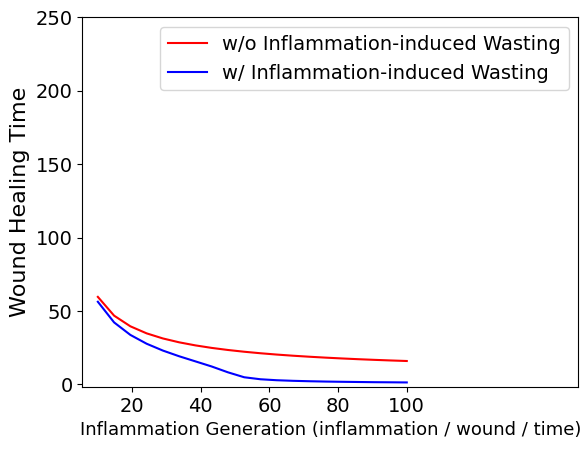

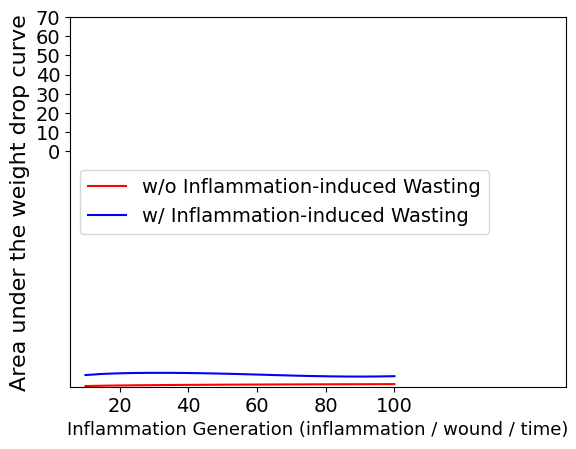

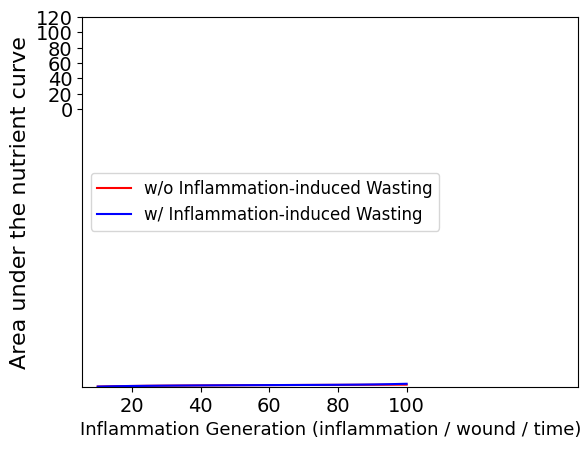

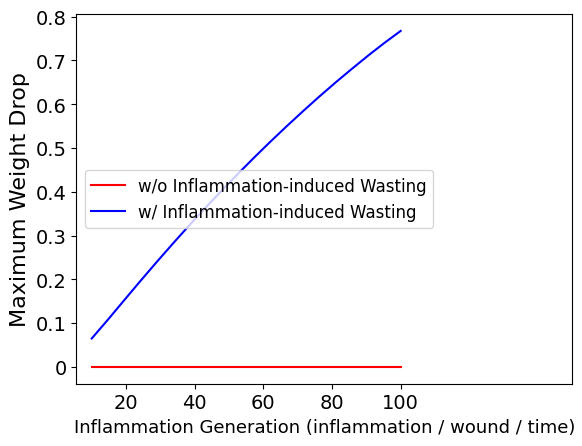

[np.float64(11.459167934283897), np.float64(1.0352629644450544), np.float64(1.0033083381563033), np.float64(inf)]


In [ ]:
finalRatios = []

figTree1, axe1 = plt.subplots()

axe1.plot(np.linspace(10, 100, numTestPoints), woundHealingTimeValues[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe1.plot(np.linspace(10, 100, numTestPoints), woundHealingTimeValues[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe1.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe1.set_ylabel("Wound Healing Time", fontsize = 16)
axe1.set_xlim(right = 150)

axe1.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe1.set_yticks([0, 50, 100, 150, 200, 250], labels = [0, 50, 100, 150, 200, 250], fontsize = 14)

axe1.legend(fontsize = 14)

finalRatios.append(woundHealingTimeValues[0][0][-1] / woundHealingTimeValues[1][0][-1])

plt.savefig("WoundHealingTimeVsInflammationGenerationForStartingWeight=160Diet=Constant2.png")

figTree2, axe2 = plt.subplots()

axe2.plot(np.linspace(10, 100, numTestPoints), weightDropIntegralVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe2.plot(np.linspace(10, 100, numTestPoints), weightDropIntegralVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe2.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe2.set_ylabel("Area under the weight drop curve", fontsize = 16)

axe2.set_xlim(right = 150)
axe2.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe2.set_yticks([0, 10, 20, 30, 40, 50, 60, 70], labels = [0, 10, 20, 30, 40, 50, 60, 70], fontsize = 14)
axe2.legend(loc = "center left", fontsize = 14)

finalRatios.append(weightDropIntegralVals[0][0][-1] / weightDropIntegralVals[1][0][-1])

plt.savefig("WeightDropIntegralVsInflammationGenerationForStartingWeight=160Diet=Constant2.png")

figTree3, axe3 = plt.subplots()
axe3.plot(np.linspace(10, 100, numTestPoints), aminoAcidDropIntegralVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe3.plot(np.linspace(10, 100, numTestPoints), aminoAcidDropIntegralVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")
axe3.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe3.set_ylabel("Area under the nutrient curve", fontsize = 16)

axe3.set_xlim(right = 150)
axe3.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe3.set_yticks([0, 20, 40, 60, 80, 100, 120], labels = [0, 20, 40, 60, 80, 100, 120], fontsize = 14)
axe3.legend(loc = "center left", fontsize = 12)

finalRatios.append(aminoAcidDropIntegralVals[0][0][-1] / aminoAcidDropIntegralVals[1][0][-1])

plt.savefig("NutrientIntegralVsInflammationGenerationForStartingWeight=160Diet=Constant2.png")

figTree4, axe4 = plt.subplots()
axe4.plot(np.linspace(10, 100, numTestPoints), maxWeightDropVals[0][0][:], 'r-', label = "w/o Inflammation-induced Wasting")
axe4.plot(np.linspace(10, 100, numTestPoints), maxWeightDropVals[1][0][:], 'b-', label = "w/ Inflammation-induced Wasting")

axe4.set_xlim(right = 150)
axe4.set_xlabel("Inflammation Generation (inflammation / wound / time)", fontsize = 13)
axe4.set_ylabel("Maximum Weight Drop", fontsize = 16)

axe4.set_xticks([20, 40, 60, 80, 100], labels = [20, 40, 60, 80, 100], fontsize = 14)
axe4.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], labels = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], fontsize = 14)
axe4.legend(fontsize = 12, loc = "center left")

finalRatios.append(maxWeightDropVals[1][0][-1] / maxWeightDropVals[0][0][-1])

plt.savefig("MaxWeightDropVsInflammationGenerationForStartingWeight=160Diet=Constant2.png")
#How should I display this data??
#Could I pick one particular representative sample?
#I suppose that could be useful, but then I would just have to report the calculated metrics in the text and not in graphical form.
#What's wrong with this format? Let me put a title on it and some axes and see how it looks

#plt.title("Wound Healing Metrics vs. Inflammation Generation")

#plt.legend()
plt.show()

print(finalRatios)